# IN718 4×4 OCRP Anchorless — Visual Walkthrough of Direct Reynolds `1x4e`

This copy is built as a visual walkthrough. It follows the current IN718 4×4 OCRP anchorless direct-Reynolds-isometric checkpoint from raw LR/HR quaternions through encoding, masking, OCRP slot construction, routing, attention, HR refinement, decoding, and feature-space error.

The central invariant remains:

```text
cubic Oh, max_harmonic_l = 4, direct Reynolds projection -> 1x4e only
```

The notebook therefore emphasizes two questions at every stage:

1. What tensor is entering this stage?
2. What changed after this stage, and where did it change spatially?

Conventions are kept explicit throughout:

- The checkpoint API receives passive scalar-first quaternions, `[w,x,y,z]`.
- The encoder internally conjugates passive input before constructing active rotation matrices.
- Feature math and misorientation/error metrics are interpreted in the active convention.
- IPF-Z images are rendered from passive scalar-first quaternions for display consistency.


## Provenance and Notebook Scope

The tensor path is the production OCRP model path loaded from the direct-Reynolds-isometric checkpoint. The notebook adds diagnostics around that path: sample loading, convention checks, crop selection, plotting, tensor summaries, and logging.

Grounding for the model configuration and source path:

| What is checked | Source |
| --- | --- |
| Direct Reynolds, `max_harmonic_l = 4`, isometric calibration, IN718 4×4 dataset | [config_new.json](/data/home/umang/Materials/Reynolds-QSR_paper/experiments/IN718/direct_reynolds_isometric_seed_runs/ocrp_direct_reynolds_isometric_l4_s42/config_new.json) |
| Model class `IsoEmbedding4x4FromSROCRP` | [config_new.json](/data/home/umang/Materials/Reynolds-QSR_paper/experiments/IN718/direct_reynolds_isometric_seed_runs/ocrp_direct_reynolds_isometric_l4_s42/config_new.json) |
| Direct Reynolds projector construction and surviving irreps | [local_iso_embedding.py](/data/home/umang/Materials/Reynolds-QSR_paper/models/local_iso_embedding.py:773) |
| Isometric calibration of direct-Reynolds blocks | [local_iso_embedding.py](/data/home/umang/Materials/Reynolds-QSR_paper/models/local_iso_embedding.py:953) |
| OCRP feature pipeline: encode → LR conv → OCRP → HR convs | [SR_4x4_from_4x1_ocrp_anchorless.py](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:2031) |
| Decoder call and FZ reduction | [SR_4x4_from_4x1_ocrp_anchorless.py](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:2021) |

The notebook intentionally distinguishes these two categories:

- **Production path:** tensors produced by the loaded model and checkpoint.
- **Diagnostic path:** code that only reads, reshapes, validates, visualizes, or compares tensors.

The runtime load cell asserts that the active model feature irreps are exactly `1x4e`; if the notebook is accidentally pointed at the older full tensor-product checkpoint, it stops immediately.


## Evaluation Sample

The notebook uses the first held-out IN718 4×4 Test pair, following the same sorted matching-key order used by `training.quaternion_dataset.QuaternionDataset`.

```text
Dataset root: /data/home/umang/Materials/Materials_data_mount/datasets/IN718_QSR_x4
Split:        Test
Sample index: 0
Sample key:   x_104
LR path:      /data/home/umang/Materials/Materials_data_mount/datasets/IN718_QSR_x4/Test/LR_Data/IN718_QSR_x4_test_lr_x_block_104.npy
HR path:      /data/home/umang/Materials/Materials_data_mount/datasets/IN718_QSR_x4/Test/HR_Data/IN718_QSR_x4_test_hr_x_block_104.npy
```

The arrays are already an aligned 4× pair:

```text
LR:  64 ×  64 × 4
HR: 256 × 256 × 4
```

The code loads both files directly and verifies the LR/HR pairing by comparing `LR` against `HR[::4, ::4]`. The component-magnitude check should identify the raw files as passive scalar-first `[w,x,y,z]`.


In [1]:
# Setup: keep orix/numba/matplotlib caches writable and deterministic for notebook runs.
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("NUMBA_CACHE_DIR", "/tmp/numba")

from pathlib import Path
import csv
import inspect
import importlib
import json
import math
import sys
import time
import warnings

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image

REPO_ROOT = Path.cwd()
for cand in [REPO_ROOT, *REPO_ROOT.parents]:
    if (cand / "models" / "SR_4x4_from_4x1_ocrp_anchorless.py").exists():
        REPO_ROOT = cand
        break
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from utils.symmetry_utils import proper_symmetry_quaternions, resolve_symmetry
from visualization.ipf_render import render_ipf_rgb

warnings.filterwarnings("ignore", category=FutureWarning)
torch.set_printoptions(precision=5, sci_mode=True, linewidth=140)
np.set_printoptions(precision=5, suppress=True)

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float32

EXP_DIR = REPO_ROOT / "experiments" / "IN718" / "direct_reynolds_isometric_seed_runs" / "ocrp_direct_reynolds_isometric_l4_s42"
CONFIG_PATH = EXP_DIR / "config_new.json"
CHECKPOINT_PATH = EXP_DIR / "checkpoints" / "best_model.pt"
DIRECT_REYNOLDS_TEST_SUMMARY = EXP_DIR / "inference" / "test_best" / "summary.json"
EXPECTED_IRREPS = "1x4e"

TEST_DATASET_ROOT = Path("/data/home/umang/Materials/Materials_data_mount/datasets/IN718_QSR_x4")
TEST_SPLIT = "Test"
TEST_SAMPLE_INDEX = 0
SAMPLE_ID = "x_104"
REP_LR_PATH = TEST_DATASET_ROOT / TEST_SPLIT / "LR_Data" / "IN718_QSR_x4_test_lr_x_block_104.npy"
REP_HR_PATH = TEST_DATASET_ROOT / TEST_SPLIT / "HR_Data" / "IN718_QSR_x4_test_hr_x_block_104.npy"
REP_IPFZ_REF_PNG = None  # No paper-side sidecar PNG for this dataset sample.
SCALE_YX = (4, 4)

# Shared diagnostic constants used by the full-field views and crop search.
BOUNDARY_THRESHOLD_DEG = 5.0
LR_CROP_SIZE = 10
LR_CROP_STRIDE = 1
BOUNDARY_DENSITY_RANGE = (0.12, 0.42)
BOUNDARY_TARGET_DENSITY = 0.26

OUT_DIR = REPO_ROOT / "analysis" / "out" / "ocrp_4x4_anchorless_direct_reynolds_isometric_visual_walkthrough"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("repo:", REPO_ROOT)
print("device:", DEVICE)
print("config:", CONFIG_PATH, CONFIG_PATH.exists())
print("checkpoint:", CHECKPOINT_PATH, CHECKPOINT_PATH.exists())
print("test summary:", DIRECT_REYNOLDS_TEST_SUMMARY, DIRECT_REYNOLDS_TEST_SUMMARY.exists())
print("expected irreps:", EXPECTED_IRREPS)
print("test dataset root:", TEST_DATASET_ROOT, TEST_DATASET_ROOT.exists())
print("test split/index:", TEST_SPLIT, TEST_SAMPLE_INDEX)
print("sample id:", SAMPLE_ID)
print("representative LR source:", REP_LR_PATH, REP_LR_PATH.exists())
print("representative HR source:", REP_HR_PATH, REP_HR_PATH.exists())
print("reference IPF-Z PNG:", REP_IPFZ_REF_PNG)
print("output dir:", OUT_DIR)


repo: /data/home/umang/Materials/Reynolds-QSR_paper
device: cuda:0
config: /data/home/umang/Materials/Reynolds-QSR_paper/experiments/IN718/direct_reynolds_isometric_seed_runs/ocrp_direct_reynolds_isometric_l4_s42/config_new.json True
checkpoint: /data/home/umang/Materials/Reynolds-QSR_paper/experiments/IN718/direct_reynolds_isometric_seed_runs/ocrp_direct_reynolds_isometric_l4_s42/checkpoints/best_model.pt True
test summary: /data/home/umang/Materials/Reynolds-QSR_paper/experiments/IN718/direct_reynolds_isometric_seed_runs/ocrp_direct_reynolds_isometric_l4_s42/inference/test_best/summary.json True
expected irreps: 1x4e
test dataset root: /data/home/umang/Materials/Materials_data_mount/datasets/IN718_QSR_x4 True
test split/index: Test 0
sample id: x_104
representative LR source: /data/home/umang/Materials/Materials_data_mount/datasets/IN718_QSR_x4/Test/LR_Data/IN718_QSR_x4_test_lr_x_block_104.npy True
representative HR source: /data/home/umang/Materials/Materials_data_mount/datasets/IN7

## Visual Roadmap

The figure below is a compact map of the whole computation. The top row is the data path. The bottom row says what each visualization in this notebook is meant to answer.


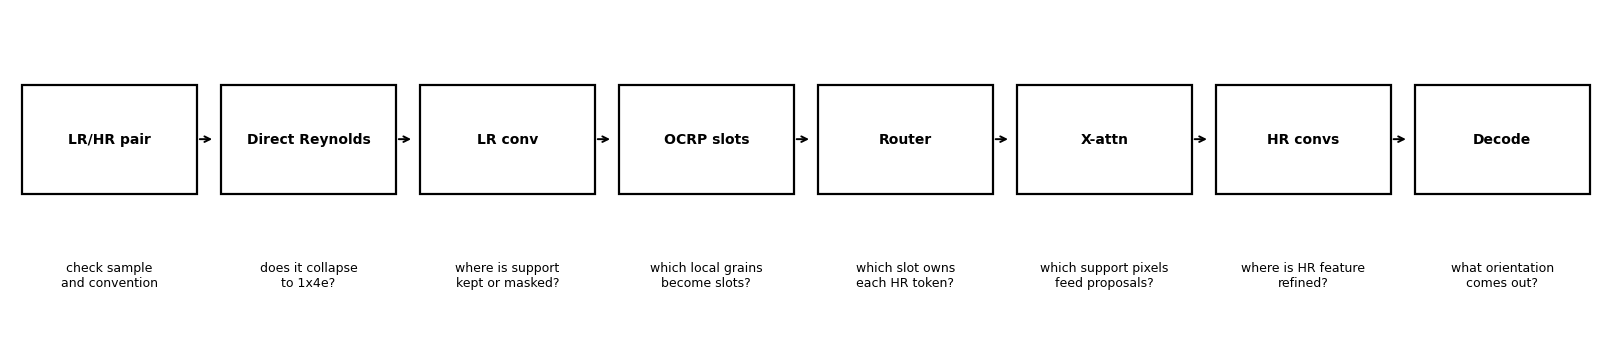

saved: /data/home/umang/Materials/Reynolds-QSR_paper/analysis/out/ocrp_4x4_anchorless_direct_reynolds_isometric_visual_walkthrough/00_pipeline_roadmap.png


In [2]:
def draw_pipeline_roadmap(out_dir: Path):
    stages = [
        ("LR/HR pair", "check sample\nand convention"),
        ("Direct Reynolds", "does it collapse\nto 1x4e?"),
        ("LR conv", "where is support\nkept or masked?"),
        ("OCRP slots", "which local grains\nbecome slots?"),
        ("Router", "which slot owns\neach HR token?"),
        ("X-attn", "which support pixels\nfeed proposals?"),
        ("HR convs", "where is HR feature\nrefined?"),
        ("Decode", "what orientation\ncomes out?"),
    ]
    fig, ax = plt.subplots(figsize=(16, 3.5), constrained_layout=True)
    ax.set_xlim(0, len(stages))
    ax.set_ylim(0, 1)
    ax.axis("off")
    for i, (title, note) in enumerate(stages):
        x = i + 0.5
        ax.add_patch(plt.Rectangle((i + 0.06, 0.46), 0.88, 0.32, fill=False, linewidth=1.6))
        ax.text(x, 0.62, title, ha="center", va="center", fontsize=10, fontweight="bold")
        ax.text(x, 0.22, note, ha="center", va="center", fontsize=9)
        if i < len(stages) - 1:
            ax.annotate("", xy=(i + 1.03, 0.62), xytext=(i + 0.94, 0.62), arrowprops=dict(arrowstyle="->", lw=1.4))
    fig.savefig(out_dir / "00_pipeline_roadmap.png", dpi=180, bbox_inches="tight")
    plt.show()
    print("saved:", out_dir / "00_pipeline_roadmap.png")

draw_pipeline_roadmap(OUT_DIR)


## Quaternion Conventions

Variable names encode the convention:

- `*_raw`: array exactly as loaded from `.npy`.
- `*_passive`: scalar-first passive quaternion `[w,x,y,z]`, which is what the checkpoint API expects.
- `*_active`: scalar-first active quaternion `[w,-x,-y,-z]`, used for feature/math explanations and active misorientation metrics.

The IN718 Test files used here are already scalar-first, so no component reorder should occur. The active form is the conjugate of passive:

$$
q_{\mathrm{active}} = q_{\mathrm{passive}}^* = [w,-x,-y,-z].
$$

The model API is left untouched: it receives passive quaternions. Inside the OCRP encoder, `forward_irreps_passive` conjugates the API input before constructing active rotation matrices. The helper `checkpoint_output_to_active_torch` is notebook-only; it converts decoded passive output to active convention for metrics.

For IPF-Z visualization, the notebook renders passive scalar-first quaternions directly. That display choice is separate from the active convention used for feature checks and misorientation errors.


In [3]:
def qnormalize_np(q: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    q = np.asarray(q, dtype=np.float32)
    q = q / np.maximum(np.linalg.norm(q, axis=-1, keepdims=True), eps)
    return np.where(q[..., :1] < 0.0, -q, q).astype(np.float32)


def qconj_np(q: np.ndarray) -> np.ndarray:
    out = np.array(q, dtype=np.float32, copy=True)
    out[..., 1:] *= -1.0
    return out


def xyzw_to_wxyz_np(q_xyzw: np.ndarray) -> np.ndarray:
    q = np.asarray(q_xyzw, dtype=np.float32)
    if q.shape[-1] != 4:
        raise ValueError(f"expected quaternion-last array, got {q.shape}")
    return np.concatenate([q[..., 3:4], q[..., :3]], axis=-1).astype(np.float32)


def infer_scalar_layout_np(q_raw: np.ndarray, *, ratio_threshold: float = 1.5) -> str:
    """Infer scalar-first/last for this real EBSD file from component magnitudes."""
    q = np.asarray(q_raw, dtype=np.float32)
    if q.shape[-1] != 4:
        raise ValueError(f"expected quaternion-last array, got {q.shape}")
    abs_mean = np.mean(np.abs(q.reshape(-1, 4)), axis=0)
    first, last = float(abs_mean[0]), float(abs_mean[-1])
    if first > ratio_threshold * max(last, 1e-12):
        return "wxyz"
    if last > ratio_threshold * max(first, 1e-12):
        return "xyzw"
    raise ValueError(
        "Cannot confidently infer scalar position from component magnitudes: "
        f"abs_mean={abs_mean}. Set RAW_SCALAR_LAYOUT explicitly."
    )


def raw_to_passive_wxyz_np(q_raw: np.ndarray, scalar_layout: str = "auto") -> tuple[np.ndarray, str, np.ndarray]:
    """Return passive scalar-first `[w,x,y,z]` quaternions and the detected raw layout."""
    q = np.asarray(q_raw, dtype=np.float32)
    layout = infer_scalar_layout_np(q) if scalar_layout == "auto" else str(scalar_layout).lower()
    abs_mean = np.mean(np.abs(q.reshape(-1, 4)), axis=0)
    if layout == "xyzw":
        q_passive = xyzw_to_wxyz_np(q)
    elif layout == "wxyz":
        q_passive = q.astype(np.float32, copy=True)
    else:
        raise ValueError(f"scalar_layout must be 'auto', 'xyzw', or 'wxyz', got {scalar_layout!r}")
    return qnormalize_np(q_passive), layout, abs_mean


def passive_to_active_np(q_passive_wxyz: np.ndarray) -> np.ndarray:
    return qnormalize_np(qconj_np(q_passive_wxyz))


def qnormalize_torch(q: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    q = q / q.norm(dim=-1, keepdim=True).clamp_min(eps)
    return torch.where(q[..., :1] < 0.0, -q, q)


def qconj_torch(q: torch.Tensor) -> torch.Tensor:
    return torch.cat([q[..., :1], -q[..., 1:]], dim=-1)


def checkpoint_output_to_active_torch(q_api: torch.Tensor) -> torch.Tensor:
    """Convert passive scalar-first checkpoint output back to active convention."""
    return qnormalize_torch(qconj_torch(q_api))


def quat_mul_np(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    aw, ax, ay, az = np.moveaxis(a, -1, 0)
    bw, bx, by, bz = np.moveaxis(b, -1, 0)
    return np.stack(
        [
            aw * bw - ax * bx - ay * by - az * bz,
            aw * bx + ax * bw + ay * bz - az * by,
            aw * by - ax * bz + ay * bw + az * bx,
            aw * bz + ax * by - ay * bx + az * bw,
        ],
        axis=-1,
    ).astype(np.float32)


SYM_CLASS = resolve_symmetry("Oh")
IPF_REF_DIR = "Z"  # Passive IPF display direction; all IPF labels derive from this value.
SYM_OPS_ACTIVE = qnormalize_np(proper_symmetry_quaternions(SYM_CLASS))
print("proper cubic rotations used for active right-symmetry metrics:", SYM_OPS_ACTIVE.shape)


proper cubic rotations used for active right-symmetry metrics: (24, 4)


## Active Misorientation and Boundary Maps

For active orientations, crystal symmetry acts on the right:

$$
q \sim q \otimes g, \qquad g \in O.
$$

The notebook therefore computes symmetry-aware angular mismatch as

$$
\theta(q_1,q_2) = 2\cos^{-1}\left(\max_{g\in O}\left|\langle q_1, q_2\otimes g\rangle\right|\right).
$$

The same active-convention distance is used for SR-vs-HR error maps and for the HR boundary mask that selects the diagnostic crop.


In [4]:
def misorientation_deg_active(q1_active: np.ndarray, q2_active: np.ndarray, sym_ops_active: np.ndarray = SYM_OPS_ACTIVE) -> np.ndarray:
    q1 = qnormalize_np(q1_active)
    q2 = qnormalize_np(q2_active)
    lead_ndim = q2.ndim - 1
    sym = sym_ops_active.reshape((1,) * lead_ndim + (sym_ops_active.shape[0], 4))
    q2_variants = quat_mul_np(q2[..., None, :], sym)
    dots = np.abs(np.sum(q1[..., None, :] * q2_variants, axis=-1)).clip(0.0, 1.0)
    best = np.max(dots, axis=-1)
    return np.degrees(2.0 * np.arccos(best)).astype(np.float32)


def active_boundary_mask(q_active: np.ndarray, threshold_deg: float = 5.0, sym_ops_active: np.ndarray = SYM_OPS_ACTIVE) -> np.ndarray:
    q = qnormalize_np(q_active)
    h, w = q.shape[:2]
    out = np.zeros((h, w), dtype=bool)
    if w > 1:
        mh = misorientation_deg_active(q[:, :-1], q[:, 1:], sym_ops_active) > float(threshold_deg)
        out[:, :-1] |= mh
        out[:, 1:] |= mh
    if h > 1:
        mv = misorientation_deg_active(q[:-1, :], q[1:, :], sym_ops_active) > float(threshold_deg)
        out[:-1, :] |= mv
        out[1:, :] |= mv
    return out


def nearest_upsample_np(x: np.ndarray, scale: int = 4) -> np.ndarray:
    return np.repeat(np.repeat(x, scale, axis=0), scale, axis=1)


def to_hwc_quat(arr: np.ndarray) -> np.ndarray:
    arr = np.asarray(arr)
    if arr.ndim != 3:
        raise ValueError(f"expected rank-3 quaternion image, got {arr.shape}")
    if arr.shape[-1] == 4:
        return arr
    if arr.shape[0] == 4:
        return np.moveaxis(arr, 0, -1)
    raise ValueError(f"cannot identify quaternion axis in shape {arr.shape}")


def show_rgb(ax, img, title):
    ax.imshow(np.clip(img, 0.0, 1.0), interpolation="nearest")
    ax.set_title(title, fontsize=10)
    ax.axis("off")


def show_scalar(ax, img, title, cmap="magma", vmin=None, vmax=None, colorbar=True):
    im = ax.imshow(img, cmap=cmap, interpolation="nearest", vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=10)
    ax.axis("off")
    if colorbar:
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return im


## Load the Paired Test Sample

The source files are a paired 4× example:

$$
(256,256)_{HR} = 4 \times (64,64)_{LR}.
$$

The code below loads the LR and HR files, normalizes them as passive scalar-first quaternions, derives active copies by conjugation, and checks that the LR sample matches stride-4 sampling of the HR map.


In [5]:
scale_y, scale_x = SCALE_YX
lr_raw = to_hwc_quat(np.load(REP_LR_PATH)).astype(np.float32, copy=False)
hr_raw = to_hwc_quat(np.load(REP_HR_PATH)).astype(np.float32, copy=False)
lr_passive_raw, LR_RAW_SCALAR_LAYOUT, LR_RAW_COMPONENT_ABS_MEAN = raw_to_passive_wxyz_np(lr_raw, scalar_layout="auto")
hr_passive_raw, RAW_SCALAR_LAYOUT, RAW_COMPONENT_ABS_MEAN = raw_to_passive_wxyz_np(hr_raw, scalar_layout="auto")
RAW_QUATERNION_CONVENTION = "passive"

# The dataset files are already paired LR/HR arrays. Keep a conservative alignment
# guard in case this cell is repointed at a different sample later.
hr_h_aligned = min((hr_passive_raw.shape[0] // scale_y) * scale_y, lr_passive_raw.shape[0] * scale_y)
hr_w_aligned = min((hr_passive_raw.shape[1] // scale_x) * scale_x, lr_passive_raw.shape[1] * scale_x)
lr_h_aligned = hr_h_aligned // scale_y
lr_w_aligned = hr_w_aligned // scale_x
hr_passive = hr_passive_raw[:hr_h_aligned, :hr_w_aligned].copy()
lr_passive = lr_passive_raw[:lr_h_aligned, :lr_w_aligned].copy()

lr_from_hr_stride = hr_passive[::scale_y, ::scale_x]
LR_HR_STRIDE_MAX_ABS_DIFF = float(np.max(np.abs(lr_passive - lr_from_hr_stride)))
LR_HR_STRIDE_MEAN_ABS_DIFF = float(np.mean(np.abs(lr_passive - lr_from_hr_stride)))

lr_active = passive_to_active_np(lr_passive)
hr_active = passive_to_active_np(hr_passive)

assert hr_active.shape[:2] == (lr_active.shape[0] * scale_y, lr_active.shape[1] * scale_x)
assert (scale_y, scale_x) == (4, 4), (scale_y, scale_x)

hr_boundary = active_boundary_mask(hr_active, threshold_deg=5.0)
print("LR raw file:", lr_raw.shape, lr_raw.dtype)
print("HR raw file:", hr_raw.shape, hr_raw.dtype)
print("LR raw component |mean|:", LR_RAW_COMPONENT_ABS_MEAN)
print("HR raw component |mean|:", RAW_COMPONENT_ABS_MEAN)
print("detected LR raw scalar layout:", LR_RAW_SCALAR_LAYOUT, "([w,x,y,z] if wxyz)")
print("detected HR raw scalar layout:", RAW_SCALAR_LAYOUT, "([w,x,y,z] if wxyz)")
print("raw quaternion convention:", RAW_QUATERNION_CONVENTION)
print("LR passive wxyz:", lr_passive.shape, lr_passive.dtype)
print("HR aligned passive wxyz:", hr_passive.shape, hr_passive.dtype)
print("LR active:", lr_active.shape, lr_active.dtype)
print("HR active:", hr_active.shape, hr_active.dtype)
print("scale:", (scale_y, scale_x))
print("LR vs HR[::4, ::4] max |diff|:", LR_HR_STRIDE_MAX_ABS_DIFF)
print("LR vs HR[::4, ::4] mean |diff|:", LR_HR_STRIDE_MEAN_ABS_DIFF)
print("HR boundary fraction @ 5 deg:", float(hr_boundary.mean()))
print("first LR raw q:", lr_raw.reshape(-1, 4)[0])
print("first HR raw q:", hr_raw.reshape(-1, 4)[0])
print("first passive wxyz q:", hr_passive.reshape(-1, 4)[0])
print("first LR active q:", lr_active.reshape(-1, 4)[0])


LR raw file: (64, 64, 4) float32
HR raw file: (256, 256, 4) float32
LR raw component |mean|: [0.94817 0.17106 0.16702 0.11932]
HR raw component |mean|: [0.94817 0.16984 0.16715 0.12029]
detected LR raw scalar layout: wxyz ([w,x,y,z] if wxyz)
detected HR raw scalar layout: wxyz ([w,x,y,z] if wxyz)
raw quaternion convention: passive
LR passive wxyz: (64, 64, 4) float32
HR aligned passive wxyz: (256, 256, 4) float32
LR active: (64, 64, 4) float32
HR active: (256, 256, 4) float32
scale: (4, 4)
LR vs HR[::4, ::4] max |diff|: 0.0
LR vs HR[::4, ::4] mean |diff|: 0.0
HR boundary fraction @ 5 deg: 0.086456298828125
first LR raw q: [ 0.96237 -0.11441 -0.10669 -0.22218]
first HR raw q: [ 0.96237 -0.11441 -0.10669 -0.22218]
first passive wxyz q: [ 0.96237 -0.11441 -0.10669 -0.22218]
first LR active q: [0.96237 0.11441 0.10669 0.22218]


## Full-Map Context

This view is not a model output. It shows the selected LR/HR Test pair in passive IPF-Z display convention and the active-convention HR boundary mask used for crop selection.

The distinction matters: IPF-Z rendering uses passive `[w,x,y,z]` quaternions for display, while boundary and error calculations use active quaternions with cubic right symmetry.


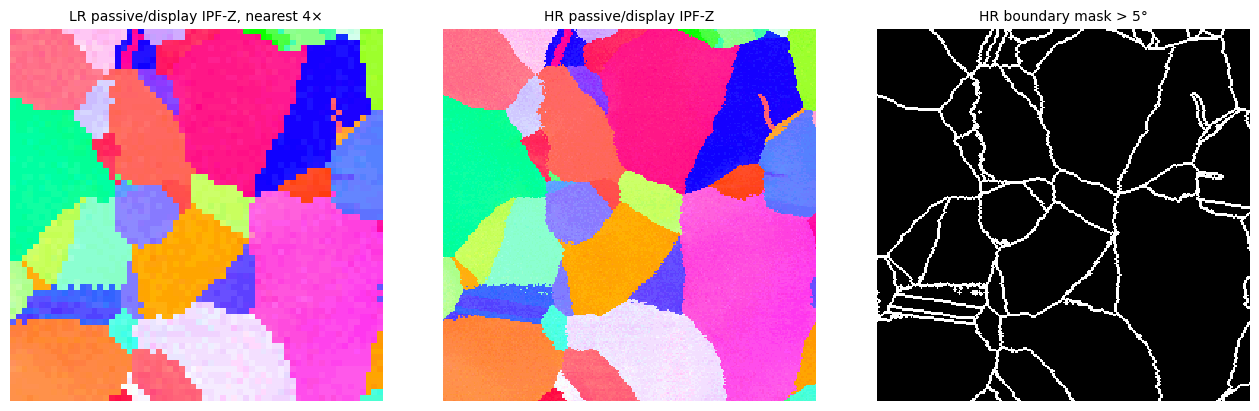

saved: /data/home/umang/Materials/Reynolds-QSR_paper/analysis/out/ocrp_4x4_anchorless_direct_reynolds_isometric_visual_walkthrough/full_map_passive_ipfz_active_boundary_context.png
No IPF-Z sidecar reference PNG configured for this dataset sample; skipped reference-PNG validation.


In [6]:
def rgb01_to_uint8(rgb: np.ndarray) -> np.ndarray:
    return np.clip(np.asarray(rgb) * 255.0, 0, 255).round().astype(np.uint8)


def extract_reference_ipfz_map_crop(path: Path) -> tuple[np.ndarray, tuple[int, int, int, int], tuple[int, int, int]]:
    """Extract the colored map panel from the sidecar MATLAB/MTEX-style IPF-Z PNG."""
    rgb = np.asarray(Image.open(path).convert("RGB"))
    # The right side is the color key; the map panel is on the left.  We find the
    # saturated, non-white IPF image region and exclude the top title/whitespace.
    left_panel = rgb[:, : max(1, int(0.50 * rgb.shape[1]))]
    arr = left_panel.astype(np.float32) / 255.0
    saturation = arr.max(axis=-1) - arr.min(axis=-1)
    yy = np.indices(left_panel.shape[:2])[0]
    mask = (saturation > 0.08) & (yy > 80)
    ys, xs = np.where(mask)
    if ys.size == 0:
        raise RuntimeError(f"Could not find IPF map panel inside {path}")
    box = (int(xs.min()), int(ys.min()), int(xs.max()) + 1, int(ys.max()) + 1)
    crop = rgb[box[1]:box[3], box[0]:box[2]]
    return crop, box, tuple(int(x) for x in rgb.shape)


lr_passive_nn = nearest_upsample_np(lr_passive, scale=4)
lr_rgb_ref = render_ipf_rgb(lr_passive_nn, SYM_CLASS, ref_dir=IPF_REF_DIR)
hr_rgb_ref = render_ipf_rgb(hr_passive, SYM_CLASS, ref_dir=IPF_REF_DIR)

fig, ax = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
show_rgb(ax[0], lr_rgb_ref, f"LR passive/display IPF-{IPF_REF_DIR}, nearest 4×")
show_rgb(ax[1], hr_rgb_ref, f"HR passive/display IPF-{IPF_REF_DIR}")
show_scalar(ax[2], hr_boundary.astype(float), "HR boundary mask > 5°", cmap="gray", colorbar=False)
fig.savefig(OUT_DIR / "full_map_passive_ipfz_active_boundary_context.png", dpi=180, bbox_inches="tight")
plt.show()
print("saved:", OUT_DIR / "full_map_passive_ipfz_active_boundary_context.png")

# Optional sidecar reference check. The first IN718 Test sample has no paper-side
# PNG sidecar configured, so this block is skipped unless REP_IPFZ_REF_PNG is set.
ipfz_reference_mae = np.nan
ipfz_reference_median = np.nan
ipfz_reference_p95 = np.nan
ipfz_reference_box = None
ipfz_reference_png_shape = None
if IPF_REF_DIR.upper() == "Z" and REP_IPFZ_REF_PNG is not None and REP_IPFZ_REF_PNG.exists():
    ref_crop_u8, ipfz_reference_box, ipfz_reference_png_shape = extract_reference_ipfz_map_crop(REP_IPFZ_REF_PNG)
    rendered_full_u8 = rgb01_to_uint8(render_ipf_rgb(hr_passive, SYM_CLASS, ref_dir="Z"))
    nearest_resample = getattr(Image, "Resampling", Image).NEAREST
    rendered_resized_u8 = np.asarray(
        Image.fromarray(rendered_full_u8).resize(
            (ref_crop_u8.shape[1], ref_crop_u8.shape[0]),
            resample=nearest_resample,
        )
    )
    ref_abs_diff = np.abs(rendered_resized_u8.astype(np.int16) - ref_crop_u8.astype(np.int16))
    ipfz_reference_mae = float(ref_abs_diff.mean())
    ipfz_reference_median = float(np.median(ref_abs_diff))
    ipfz_reference_p95 = float(np.percentile(ref_abs_diff, 95))

    fig_val, ax_val = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
    show_rgb(ax_val[0], ref_crop_u8 / 255.0, "reference PNG map crop")
    show_rgb(ax_val[1], rendered_resized_u8 / 255.0, "notebook passive IPF-Z render")
    show_scalar(ax_val[2], ref_abs_diff.mean(axis=-1), "absolute RGB diff", cmap="magma", vmin=0, vmax=max(10.0, float(np.percentile(ref_abs_diff, 99))))
    fig_val.savefig(OUT_DIR / "open718_ipfz_reference_match.png", dpi=180, bbox_inches="tight")
    plt.show()

    print("IPF-Z reference crop box:", ipfz_reference_box, "PNG shape:", ipfz_reference_png_shape)
    print("passive wxyz IPF-Z vs reference PNG RGB error:")
    print("  MAE:", ipfz_reference_mae)
    print("  median:", ipfz_reference_median)
    print("  p95:", ipfz_reference_p95)
    print("saved:", OUT_DIR / "open718_ipfz_reference_match.png")
else:
    print("No IPF-Z sidecar reference PNG configured for this dataset sample; skipped reference-PNG validation.")


## What the Network Sees Before Any Learning

This panel separates three things that are easy to conflate: the LR input grid, the HR target grid, and the active boundary mask used only for diagnostics. The LR image is nearest-neighbor expanded so it can be visually compared with HR at the same pixel size.


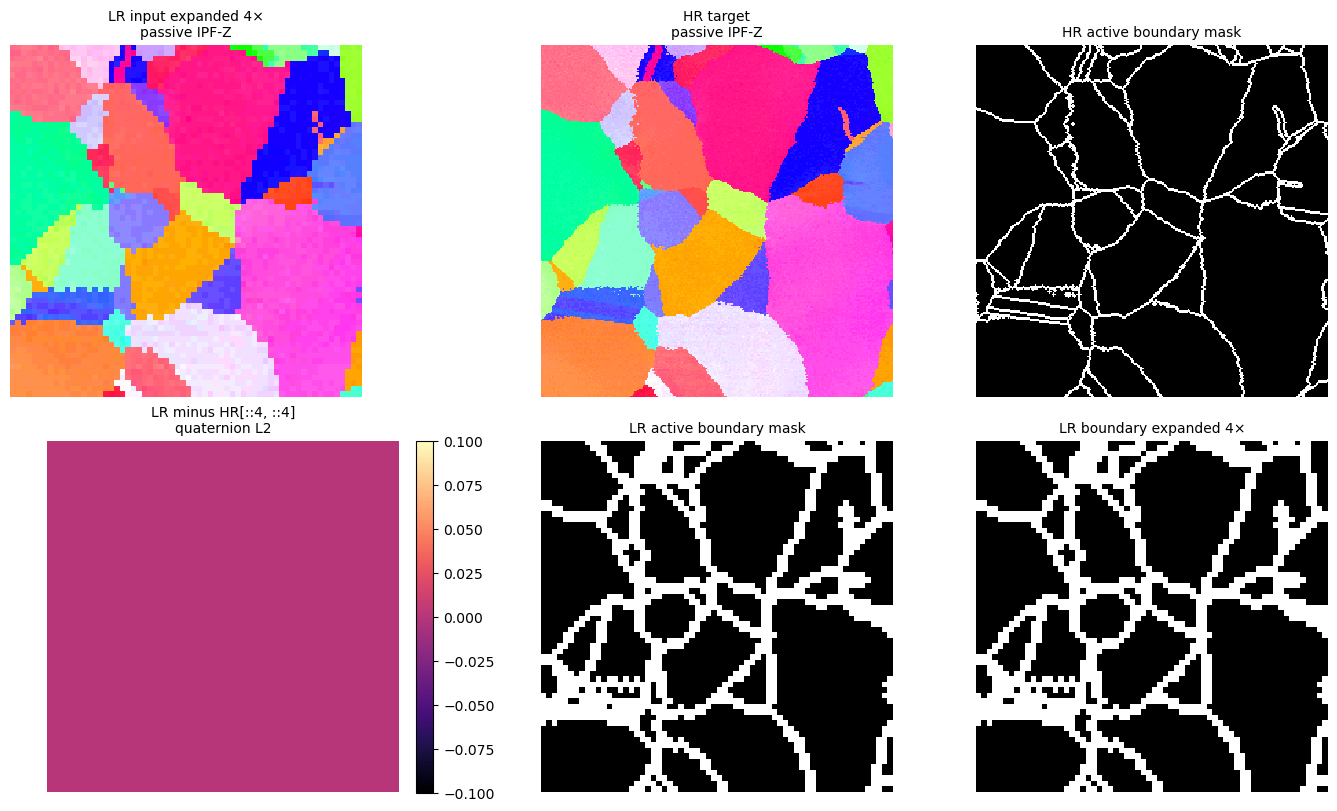

stride check max |diff|: 0.0
saved: /data/home/umang/Materials/Reynolds-QSR_paper/analysis/out/ocrp_4x4_anchorless_direct_reynolds_isometric_visual_walkthrough/01_input_pair_and_boundary_context.png


In [7]:
lr_hr_stride_error = np.linalg.norm(lr_passive - lr_from_hr_stride, axis=-1)
fig, ax = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
show_rgb(ax[0, 0], render_ipf_rgb(nearest_upsample_np(lr_passive, 4), SYM_CLASS, ref_dir=IPF_REF_DIR), f"LR input expanded 4×\npassive IPF-{IPF_REF_DIR}")
show_rgb(ax[0, 1], render_ipf_rgb(hr_passive, SYM_CLASS, ref_dir=IPF_REF_DIR), f"HR target\npassive IPF-{IPF_REF_DIR}")
show_scalar(ax[0, 2], hr_boundary.astype(float), "HR active boundary mask", cmap="gray", colorbar=False)
show_scalar(ax[1, 0], lr_hr_stride_error, "LR minus HR[::4, ::4]\nquaternion L2", cmap="magma")
show_scalar(ax[1, 1], active_boundary_mask(lr_active, threshold_deg=BOUNDARY_THRESHOLD_DEG).astype(float), "LR active boundary mask", cmap="gray", colorbar=False)
show_scalar(ax[1, 2], nearest_upsample_np(active_boundary_mask(lr_active, threshold_deg=BOUNDARY_THRESHOLD_DEG).astype(float), 4), "LR boundary expanded 4×", cmap="gray", colorbar=False)
fig.savefig(OUT_DIR / "01_input_pair_and_boundary_context.png", dpi=180, bbox_inches="tight")
plt.show()
print("stride check max |diff|:", LR_HR_STRIDE_MAX_ABS_DIFF)
print("saved:", OUT_DIR / "01_input_pair_and_boundary_context.png")


## Boundary-Rich Crop Selection

The full test field is too large for interactive layer-by-layer decoding, so the live checkpoint pass runs on a crop.

The crop is selected in LR coordinates. Each candidate crop is scored using the corresponding HR boundary mask. The score favors crops that are informative for a 4× upsampler:

- boundaries near the crop center;
- mixed `4×4` HR subcells inside LR pixels;
- moderate, not saturated, boundary density;
- boundary structure that crosses a meaningful part of the crop.

The default crop is `10×10` LR pixels, producing a `40×40` HR crop.


In [8]:
# Uses shared diagnostic constants from the setup cell.

score_shape = (
    max(0, lr_active.shape[0] - LR_CROP_SIZE + 1),
    max(0, lr_active.shape[1] - LR_CROP_SIZE + 1),
)
crop_score_map = np.full(score_shape, np.nan, dtype=np.float32)
crop_boundary_density_map = np.full(score_shape, np.nan, dtype=np.float32)
crop_mixed_cell_fraction_map = np.full(score_shape, np.nan, dtype=np.float32)
crop_central_density_map = np.full(score_shape, np.nan, dtype=np.float32)
crop_crossing_spread_map = np.full(score_shape, np.nan, dtype=np.float32)

best = None
lr_center_r = 0.5 * (lr_active.shape[0] - LR_CROP_SIZE)
lr_center_c = 0.5 * (lr_active.shape[1] - LR_CROP_SIZE)
for r0 in range(0, lr_active.shape[0] - LR_CROP_SIZE + 1, LR_CROP_STRIDE):
    for c0 in range(0, lr_active.shape[1] - LR_CROP_SIZE + 1, LR_CROP_STRIDE):
        hslice = slice(r0 * 4, (r0 + LR_CROP_SIZE) * 4)
        wslice = slice(c0 * 4, (c0 + LR_CROP_SIZE) * 4)
        bpatch = hr_boundary[hslice, wslice]
        boundary_density_candidate = float(bpatch.mean())
        if not (BOUNDARY_DENSITY_RANGE[0] <= boundary_density_candidate <= BOUNDARY_DENSITY_RANGE[1]):
            continue

        cell_boundary = bpatch.reshape(LR_CROP_SIZE, 4, LR_CROP_SIZE, 4).mean(axis=(1, 3))
        mixed_cell_fraction = float(((cell_boundary > 0.05) & (cell_boundary < 0.95)).mean())
        strong_cell_fraction = float((cell_boundary > 0.15).mean())

        h_hr, w_hr = bpatch.shape
        central = bpatch[h_hr // 4 : 3 * h_hr // 4, w_hr // 4 : 3 * w_hr // 4]
        central_boundary_density = float(central.mean())
        row_spread = float((bpatch.mean(axis=1) > 0.05).mean())
        col_spread = float((bpatch.mean(axis=0) > 0.05).mean())
        crossing_spread = max(row_spread, col_spread)

        density_score = 1.0 - abs(boundary_density_candidate - BOUNDARY_TARGET_DENSITY) / BOUNDARY_TARGET_DENSITY
        center_penalty = 6e-5 * ((r0 - lr_center_r) ** 2 + (c0 - lr_center_c) ** 2)
        score = (
            3.0 * mixed_cell_fraction
            + 2.2 * central_boundary_density
            + 0.9 * crossing_spread
            + 1.2 * max(0.0, density_score)
            + 0.5 * strong_cell_fraction
            - center_penalty
        )

        crop_score_map[r0, c0] = score
        crop_boundary_density_map[r0, c0] = boundary_density_candidate
        crop_mixed_cell_fraction_map[r0, c0] = mixed_cell_fraction
        crop_central_density_map[r0, c0] = central_boundary_density
        crop_crossing_spread_map[r0, c0] = crossing_spread

        if best is None or score > best[0]:
            best = (
                score,
                r0,
                c0,
                boundary_density_candidate,
                mixed_cell_fraction,
                central_boundary_density,
                crossing_spread,
                strong_cell_fraction,
            )

if best is None:
    raise RuntimeError("No crop satisfied the boundary showcase criteria; relax BOUNDARY_DENSITY_RANGE.")

(
    crop_score,
    LR_R0,
    LR_C0,
    boundary_density,
    mixed_cell_fraction,
    central_boundary_density,
    crossing_spread,
    strong_cell_fraction,
) = best
HR_R0, HR_C0 = LR_R0 * 4, LR_C0 * 4
HR_CROP_SIZE = LR_CROP_SIZE * 4

lr_crop_passive = lr_passive[LR_R0:LR_R0 + LR_CROP_SIZE, LR_C0:LR_C0 + LR_CROP_SIZE]
hr_crop_passive = hr_passive[HR_R0:HR_R0 + HR_CROP_SIZE, HR_C0:HR_C0 + HR_CROP_SIZE]
lr_crop_active = lr_active[LR_R0:LR_R0 + LR_CROP_SIZE, LR_C0:LR_C0 + LR_CROP_SIZE]
hr_crop_active = hr_active[HR_R0:HR_R0 + HR_CROP_SIZE, HR_C0:HR_C0 + HR_CROP_SIZE]
hr_crop_boundary = hr_boundary[HR_R0:HR_R0 + HR_CROP_SIZE, HR_C0:HR_C0 + HR_CROP_SIZE]

print("selected LR crop row/col:", (LR_R0, LR_C0), "size:", LR_CROP_SIZE)
print("aligned HR crop row/col:", (HR_R0, HR_C0), "size:", HR_CROP_SIZE)
print("HR boundary density in crop:", boundary_density)
print("mixed 4×4 HR subcell fraction:", mixed_cell_fraction)
print("central boundary density:", central_boundary_density)
print("boundary crossing spread:", crossing_spread)
print("strong boundary subcell fraction:", strong_cell_fraction)
print("crop showcase score:", crop_score)
print("candidate crops scored:", int(np.isfinite(crop_score_map).sum()))


selected LR crop row/col: (41, 0) size: 10
aligned HR crop row/col: (164, 0) size: 40
HR boundary density in crop: 0.271875
mixed 4×4 HR subcell fraction: 0.68
central boundary density: 0.355
boundary crossing spread: 1.0
strong boundary subcell fraction: 0.57
crop showcase score: 5.095692307692308
candidate crops scored: 828


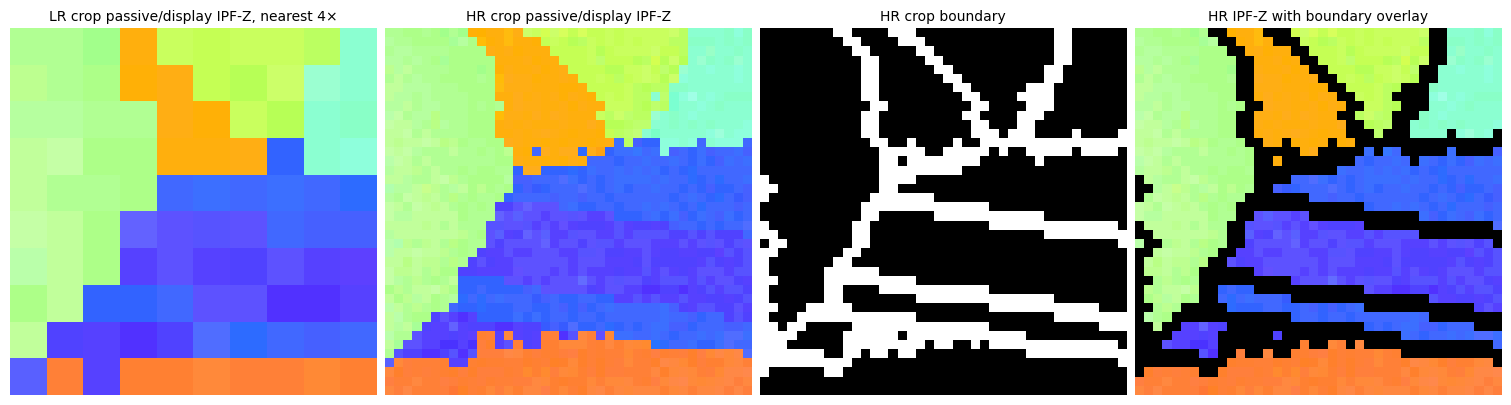

saved: /data/home/umang/Materials/Reynolds-QSR_paper/analysis/out/ocrp_4x4_anchorless_direct_reynolds_isometric_visual_walkthrough/selected_boundary_crop_passive_ipfz_active_boundary.png


In [9]:
fig, ax = plt.subplots(1, 4, figsize=(15, 4), constrained_layout=True)
show_rgb(ax[0], render_ipf_rgb(nearest_upsample_np(lr_crop_passive, 4), SYM_CLASS, ref_dir=IPF_REF_DIR), f"LR crop passive/display IPF-{IPF_REF_DIR}, nearest 4×")
show_rgb(ax[1], render_ipf_rgb(hr_crop_passive, SYM_CLASS, ref_dir=IPF_REF_DIR), f"HR crop passive/display IPF-{IPF_REF_DIR}")
show_scalar(ax[2], hr_crop_boundary.astype(float), "HR crop boundary", cmap="gray", colorbar=False)
# Overlay boundary on HR RGB.
overlay = render_ipf_rgb(hr_crop_passive, SYM_CLASS, ref_dir=IPF_REF_DIR).copy()
overlay[hr_crop_boundary] = np.array([0.0, 0.0, 0.0])
show_rgb(ax[3], overlay, f"HR IPF-{IPF_REF_DIR} with boundary overlay")
fig.savefig(OUT_DIR / "selected_boundary_crop_passive_ipfz_active_boundary.png", dpi=200, bbox_inches="tight")
plt.show()
print("saved:", OUT_DIR / "selected_boundary_crop_passive_ipfz_active_boundary.png")


## Why This Crop Was Chosen

The selected crop is not arbitrary. The score map shows candidate LR crop origins that satisfy the boundary-density range. The rectangle shows the chosen HR crop. High-scoring crops contain mixed HR subcells inside LR pixels, which is exactly where a 4× model has to infer subpixel boundary geometry.


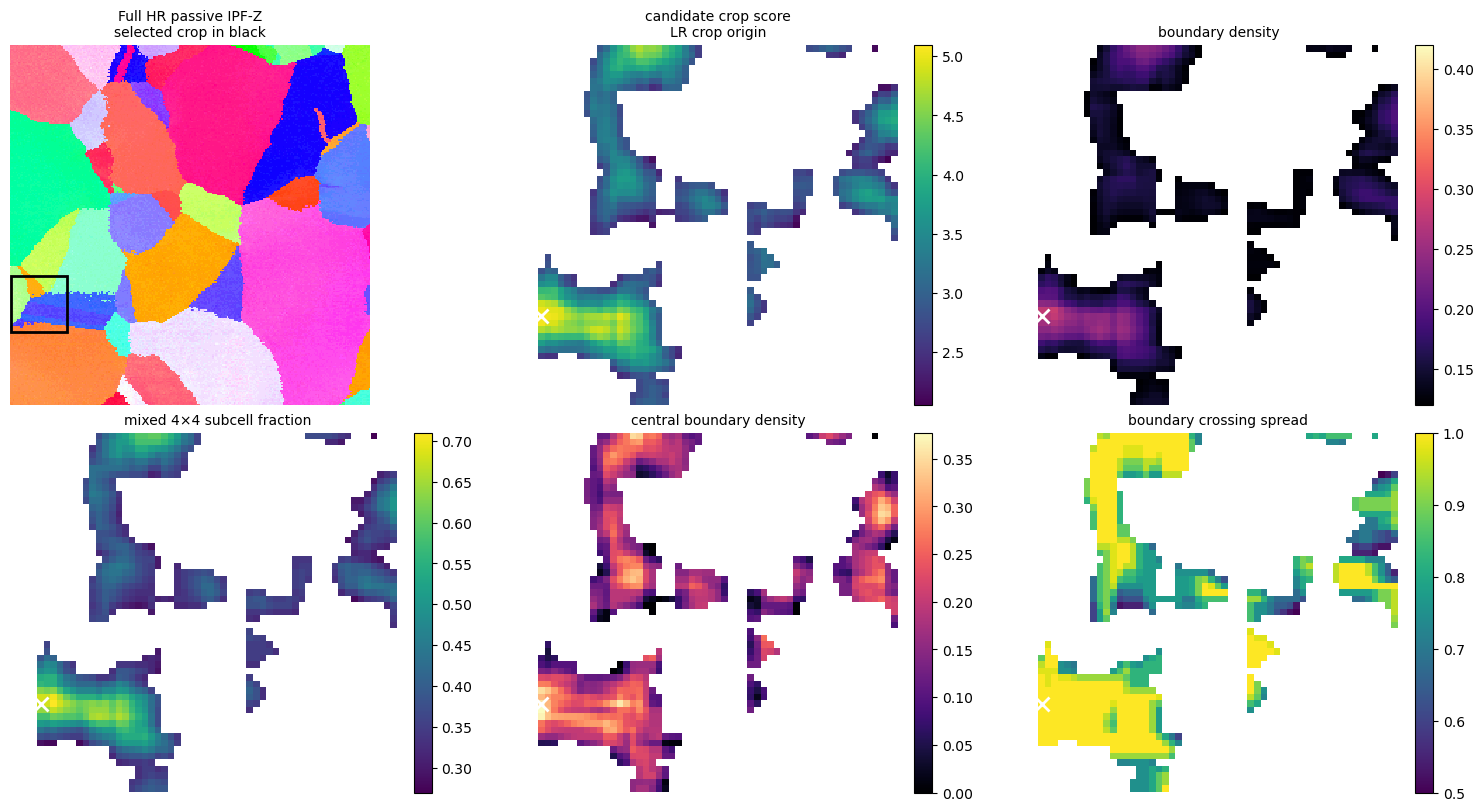

selected score components:
  score: 5.095692307692308
  boundary density: 0.271875
  mixed subcells: 0.68
  central density: 0.355
  crossing spread: 1.0
saved: /data/home/umang/Materials/Reynolds-QSR_paper/analysis/out/ocrp_4x4_anchorless_direct_reynolds_isometric_visual_walkthrough/02_crop_selection_score_maps.png


In [10]:
from matplotlib.patches import Rectangle

hr_rgb_for_crop = render_ipf_rgb(hr_passive, SYM_CLASS, ref_dir=IPF_REF_DIR)
fig, ax = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
show_rgb(ax[0, 0], hr_rgb_for_crop, f"Full HR passive IPF-{IPF_REF_DIR}\nselected crop in black")
ax[0, 0].add_patch(Rectangle((HR_C0, HR_R0), HR_CROP_SIZE, HR_CROP_SIZE, fill=False, edgecolor="black", linewidth=2.0))
show_scalar(ax[0, 1], crop_score_map, "candidate crop score\nLR crop origin", cmap="viridis")
ax[0, 1].plot(LR_C0, LR_R0, marker="x", color="white", markersize=10, markeredgewidth=2)
show_scalar(ax[0, 2], crop_boundary_density_map, "boundary density", cmap="magma", vmin=BOUNDARY_DENSITY_RANGE[0], vmax=BOUNDARY_DENSITY_RANGE[1])
ax[0, 2].plot(LR_C0, LR_R0, marker="x", color="white", markersize=10, markeredgewidth=2)
show_scalar(ax[1, 0], crop_mixed_cell_fraction_map, "mixed 4×4 subcell fraction", cmap="viridis")
ax[1, 0].plot(LR_C0, LR_R0, marker="x", color="white", markersize=10, markeredgewidth=2)
show_scalar(ax[1, 1], crop_central_density_map, "central boundary density", cmap="magma")
ax[1, 1].plot(LR_C0, LR_R0, marker="x", color="white", markersize=10, markeredgewidth=2)
show_scalar(ax[1, 2], crop_crossing_spread_map, "boundary crossing spread", cmap="viridis")
ax[1, 2].plot(LR_C0, LR_R0, marker="x", color="white", markersize=10, markeredgewidth=2)
fig.savefig(OUT_DIR / "02_crop_selection_score_maps.png", dpi=180, bbox_inches="tight")
plt.show()
print("selected score components:")
print("  score:", crop_score)
print("  boundary density:", boundary_density)
print("  mixed subcells:", mixed_cell_fraction)
print("  central density:", central_boundary_density)
print("  crossing spread:", crossing_spread)
print("saved:", OUT_DIR / "02_crop_selection_score_maps.png")


# Load the Direct-Reynolds-Isometric Checkpoint

The checkpoint is the seed-42 best model from the current direct-Reynolds-isometric IN718 run:

```text
experiments/IN718/direct_reynolds_isometric_seed_runs/ocrp_direct_reynolds_isometric_l4_s42/checkpoints/best_model.pt
```

Key encoder settings from the config:

```json
"embedding_mode": "direct_reynolds",
"max_harmonic_l": 4,
"embedding_metric_calibration": "isometric"
```

For cubic `Oh`, the direct Reynolds projector through `l=4` should leave only one `l=4` even-parity block: `1x4e`. The code below loads the checkpoint and asserts this representation at runtime.


In [11]:
def build_model_from_config(config_path: Path, checkpoint_path: Path, device: torch.device):
    cfg = json.loads(config_path.read_text())
    model_cfg = cfg.get("model", {})
    module_name = model_cfg.get("model_module", "models.SR_4x4_from_4x1_ocrp_anchorless")
    class_name = model_cfg.get("model_class", "IsoEmbedding4x4FromSROCRP")
    module = importlib.import_module(module_name)
    cls = getattr(module, class_name)

    sig = inspect.signature(cls)
    kwargs = {k: v for k, v in cfg.items() if k in sig.parameters}
    kwargs["device"] = device
    kwargs["decoder_eager_init"] = False

    model = cls(**kwargs).to(device).eval()
    ckpt = torch.load(checkpoint_path, map_location=device)
    state = ckpt.get("model_state_dict", ckpt)
    load_result = model.load_state_dict(state, strict=True)
    return cfg, ckpt, model, load_result


cfg, ckpt, model, load_result = build_model_from_config(CONFIG_PATH, CHECKPOINT_PATH, DEVICE)
actual_irreps = str(model.irreps_feat).replace(" ", "")
expected_irreps = EXPECTED_IRREPS.replace(" ", "")
if actual_irreps != expected_irreps:
    raise RuntimeError(
        f"Expected direct-Reynolds IN718 features to be {EXPECTED_IRREPS}, got {model.irreps_feat}. "
        "This notebook should not be run on the older tensor-product/full-irrep checkpoint."
    )

print("checkpoint saved epoch field:", ckpt.get("epoch"))
print("load result:", load_result)
print("model class:", model.__class__.__name__)
print("embedding_mode:", cfg.get("embedding_mode"))
print("max_harmonic_l:", cfg.get("max_harmonic_l"))
print("embedding_metric_calibration:", cfg.get("embedding_metric_calibration"))
print("config feature_irreps:", cfg.get("feature_irreps"))
print("model feature_irreps:", model.feature_irreps)
print("encoder irreps_full:", model.encoder.irreps_full)
print("encoder irreps_a1:", model.encoder.irreps_a1)
print("active feature irreps:", model.irreps_feat)
print("feature_dim:", model.feature_dim)
print("upsample_factor:", model.upsample_factor)
print("OCRP window_size:", model.ocrp.window_size)
print("OCRP kmax_slots:", model.ocrp.kmax_slots)
print("OCRP HR patch shape:", model.ocrp.hr_patch_shape)
print("decoder kwargs:", model._decoder_kwargs)


checkpoint saved epoch field: 11
load result: <All keys matched successfully>
model class: IsoEmbedding4x4FromSROCRP
embedding_mode: direct_reynolds
max_harmonic_l: 4
embedding_metric_calibration: isometric
config feature_irreps: full
model feature_irreps: full
encoder irreps_full: 1x4e
encoder irreps_a1: 1x4e
active feature irreps: 1x4e
feature_dim: 9
upsample_factor: (4, 4)
OCRP window_size: 9
OCRP kmax_slots: 6
OCRP HR patch shape: (4, 4)
decoder kwargs: {'encoder': LocalIsoCrystalEncoder(
  (embedding): LocalIsoCrystalEmbedding(
    (blocks): ModuleList(
      (0): Module()
    )
  )
), 'cubochoric_resolution': 1, 'method': 'cubochoric', 'num_starts': 2, 'steps': 60, 'lr': 0.03, 'target_irreps': 'full', 'max_table_rows': None, 'table_cache_dir': 'out/decoder_lookup_tables'}


## Direct Reynolds Projection Check

This is the representation sanity check. The configuration says `feature_irreps = full`, but in the direct-Reynolds cubic projector path, `full` and `a1` both collapse to the same surviving `1x4e` block. The loaded model must therefore expose a 9-dimensional feature space.


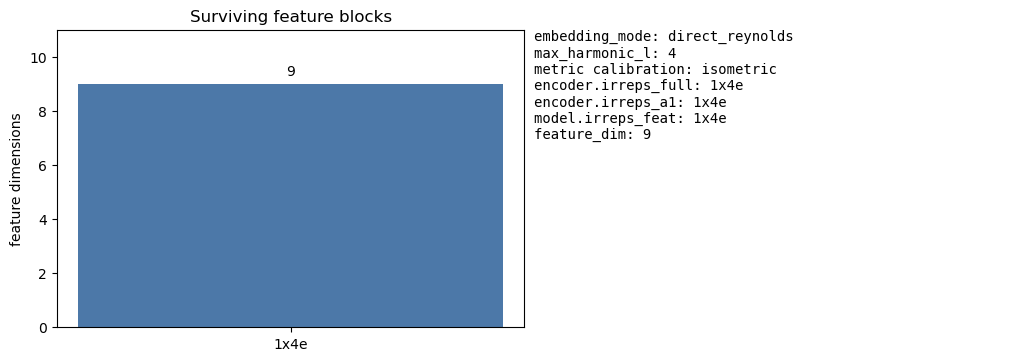

saved: /data/home/umang/Materials/Reynolds-QSR_paper/analysis/out/ocrp_4x4_anchorless_direct_reynolds_isometric_visual_walkthrough/03_direct_reynolds_irrep_survival.png


In [12]:
irrep_labels = [str(mul_ir) for mul_ir in model.irreps_feat]
irrep_dims = [int(mul_ir.dim) for mul_ir in model.irreps_feat]
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
ax[0].bar(irrep_labels, irrep_dims, color="#4C78A8")
ax[0].set_ylabel("feature dimensions")
ax[0].set_title("Surviving feature blocks")
ax[0].set_ylim(0, max(irrep_dims) + 2)
for x, y in zip(irrep_labels, irrep_dims):
    ax[0].text(x, y + 0.2, str(y), ha="center", va="bottom")
ax[1].axis("off")
lines = [
    f"embedding_mode: {cfg.get('embedding_mode')}",
    f"max_harmonic_l: {cfg.get('max_harmonic_l')}",
    f"metric calibration: {cfg.get('embedding_metric_calibration')}",
    f"encoder.irreps_full: {model.encoder.irreps_full}",
    f"encoder.irreps_a1: {model.encoder.irreps_a1}",
    f"model.irreps_feat: {model.irreps_feat}",
    f"feature_dim: {model.feature_dim}",
]
ax[1].text(0.0, 1.0, "\n".join(lines), ha="left", va="top", family="monospace", fontsize=10)
fig.savefig(OUT_DIR / "03_direct_reynolds_irrep_survival.png", dpi=180, bbox_inches="tight")
plt.show()
print("saved:", OUT_DIR / "03_direct_reynolds_irrep_survival.png")


# Live Forward Pass on the Selected Crop

The live pass uses the real model modules and stops before decoding so the intermediate feature tensors can be inspected.

The feature path is:

```text
passive LR crop [w,x,y,z]
  -> checkpoint API
  -> encoder conjugates to active internally
  -> direct Reynolds projector, isometric calibrated
  -> 1x4e LR features
  -> LR masked equivariant convolution
  -> OCRP support banks, clustering, routing, member cross-attention
  -> assembled raw HR 1x4e features
  -> HR masked equivariant convolutions
  -> final HR 1x4e features
```

All tensors in this path come from the loaded production model. The notebook code around the call only prepares the crop, records shapes, and plots diagnostics.


In [13]:
q_lr_crop_active_t = torch.from_numpy(lr_crop_active).to(device=DEVICE, dtype=DTYPE).reshape(1, -1, 4)
q_lr_crop_api_t = torch.from_numpy(lr_crop_passive).to(device=DEVICE, dtype=DTYPE).reshape(1, -1, 4)
lr_shape_crop = (LR_CROP_SIZE, LR_CROP_SIZE)

with torch.no_grad():
    feat_lr_flat = model.encode(q_lr_crop_api_t.reshape(-1, 4))
    feat_lr = feat_lr_flat.reshape(1, -1, feat_lr_flat.shape[-1])
    feat_hr, hr_shape_crop, aux = model._forward_sr_features(
        lr_quats=q_lr_crop_api_t,
        feat_lr=feat_lr,
        lr_shape=lr_shape_crop,
        return_aux=True,
    )

print("input active q crop:", tuple(q_lr_crop_active_t.shape))
print("checkpoint API input tensor, passive wxyz:", tuple(q_lr_crop_api_t.shape))
print("encoded LR features:", tuple(feat_lr.shape))
print("final HR features:", tuple(feat_hr.shape))
print("hr_shape_crop:", hr_shape_crop)
print("aux keys:", sorted(aux.keys()))
print("probe stages:")
for stage in aux["probe_stages"]:
    print(" ", stage["name"], tuple(stage["feat"].shape), "image_shape=", stage["shape"])


input active q crop: (1, 100, 4)
checkpoint API input tensor, passive wxyz: (1, 100, 4)
encoded LR features: (1, 100, 9)
final HR features: (1, 1600, 9)
hr_shape_crop: (40, 40)
aux keys: ['bank_f', 'bank_q', 'cluster_ids', 'feat_hr_post_hr_conv', 'feat_hr_post_hr_conv1', 'feat_hr_post_hr_conv2', 'feat_hr_raw_ocrp', 'feat_lr_encode', 'feat_lr_pre_ocrp', 'hr_patch_shape', 'hr_patch_size', 'hr_patch_tokens', 'lr_padded_shape', 'macro_lr_stride_shape', 'macro_lr_tile_size', 'ocrp_mode', 'owner_idx', 'patch_out', 'patch_prop', 'pool_chunk_size', 'probe_stages', 'proposal_chunk_size', 'proposal_mode', 'proposal_tconv_chunk_size', 'proposal_token_chunk_size', 'router_chunk_size', 'router_logits', 'slot_anchor_alpha', 'slot_ctx', 'slot_mask', 'slot_meta', 'slot_pool_alpha', 'slot_pooled_ctx', 'slot_valid', 'support_grid_shape', 'token_conditioned_member_bias', 'xattn_alpha']
probe stages:
  encode_lr (1, 100, 9) image_shape= (10, 10)
  lr_conv1_post (1, 100, 9) image_shape= (10, 10)
  ocrp_hr_

## Shape Ledger and Tensor Statistics

This table is the first checkpoint sanity pass. It checks token counts, feature dimensions, and aux tensor shapes against the selected crop.

Expected for the default `10×10` LR crop:

- LR token count: `10×10 = 100`.
- HR token count after 4×4 upsampling: `40×40 = 1600`.
- Feature dimension: `9`, from the single `1x4e` block.
- OCRP local window: `9×9 = 81` support members.
- OCRP slots: `K = 6`.
- HR patch tokens per LR pixel: `4×4 = 16`.


In [14]:
def tensor_stats(name: str, t: torch.Tensor) -> dict:
    x = t.detach().float().cpu()
    finite = torch.isfinite(x)
    if finite.any():
        xf = x[finite]
        return {
            "name": name,
            "shape": tuple(t.shape),
            "dtype": str(t.dtype),
            "finite_frac": float(finite.float().mean()),
            "mean": float(xf.mean()),
            "std": float(xf.std(unbiased=False)),
            "min": float(xf.min()),
            "max": float(xf.max()),
            "rms": float(torch.sqrt((xf * xf).mean())),
        }
    return {"name": name, "shape": tuple(t.shape), "dtype": str(t.dtype), "finite_frac": 0.0}

summary_names = [
    "feat_lr_encode",
    "feat_lr_pre_ocrp",
    "bank_q",
    "bank_f",
    "cluster_ids",
    "slot_mask",
    "slot_valid",
    "slot_meta",
    "router_logits",
    "owner_idx",
    "patch_prop",
    "patch_out",
    "feat_hr_raw_ocrp",
    "feat_hr_post_hr_conv1",
    "feat_hr_post_hr_conv2",
    "feat_hr_post_hr_conv",
]

stage_stats = []
for name in summary_names:
    val = aux.get(name)
    if isinstance(val, torch.Tensor):
        stage_stats.append(tensor_stats(name, val))

for row in stage_stats:
    print(f"{row['name']:>24s} shape={row['shape']} dtype={row['dtype']} mean={row.get('mean', float('nan')):+.4e} std={row.get('std', float('nan')):.4e} finite={row['finite_frac']:.3f}")

csv_path = OUT_DIR / "stage_tensor_stats.csv"
with csv_path.open("w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["name", "shape", "dtype", "finite_frac", "mean", "std", "min", "max", "rms"])
    writer.writeheader()
    for row in stage_stats:
        writer.writerow(row)
print("saved:", csv_path)


          feat_lr_encode shape=(1, 100, 9) dtype=torch.float32 mean=-8.7278e-03 std=1.2880e-01 finite=1.000
        feat_lr_pre_ocrp shape=(1, 100, 9) dtype=torch.float32 mean=-1.2793e-02 std=1.8880e-01 finite=1.000
                  bank_q shape=(1, 100, 81, 4) dtype=torch.float32 mean=+2.1092e-01 std=4.5333e-01 finite=1.000
                  bank_f shape=(1, 100, 81, 9) dtype=torch.float32 mean=-1.2982e-02 std=1.8879e-01 finite=1.000
             cluster_ids shape=(1, 100, 81) dtype=torch.int64 mean=+2.0592e+01 std=2.3418e+01 finite=1.000
               slot_mask shape=(1, 100, 6, 81) dtype=torch.bool mean=+1.5864e-01 std=3.6534e-01 finite=1.000
              slot_valid shape=(1, 100, 6) dtype=torch.float32 mean=+9.5000e-01 std=2.1794e-01 finite=1.000
               slot_meta shape=(1, 100, 6, 11) dtype=torch.float32 mean=+2.1324e-01 std=4.4203e-01 finite=1.000
           router_logits shape=(1, 100, 16, 6) dtype=torch.float32 mean=-5.0018e+02 std=2.1794e+03 finite=1.000
            

# Stage 1 — Direct-Reynolds `1x4e` Encoding

The encoder maps each orientation to an SO(3)-equivariant feature using the direct Reynolds projector. For this cubic `Oh`, `max_harmonic_l = 4` run, the surviving projected representation is

$$
1 \times 4e.
$$

So each pixel has a 9-dimensional feature:

$$
\dim(4e) = 2\cdot4 + 1 = 9.
$$

The cell below plots total feature norm and the `1x4e` block norm before and after the LR masked convolution. It also asserts that no `1x2e` block is present.


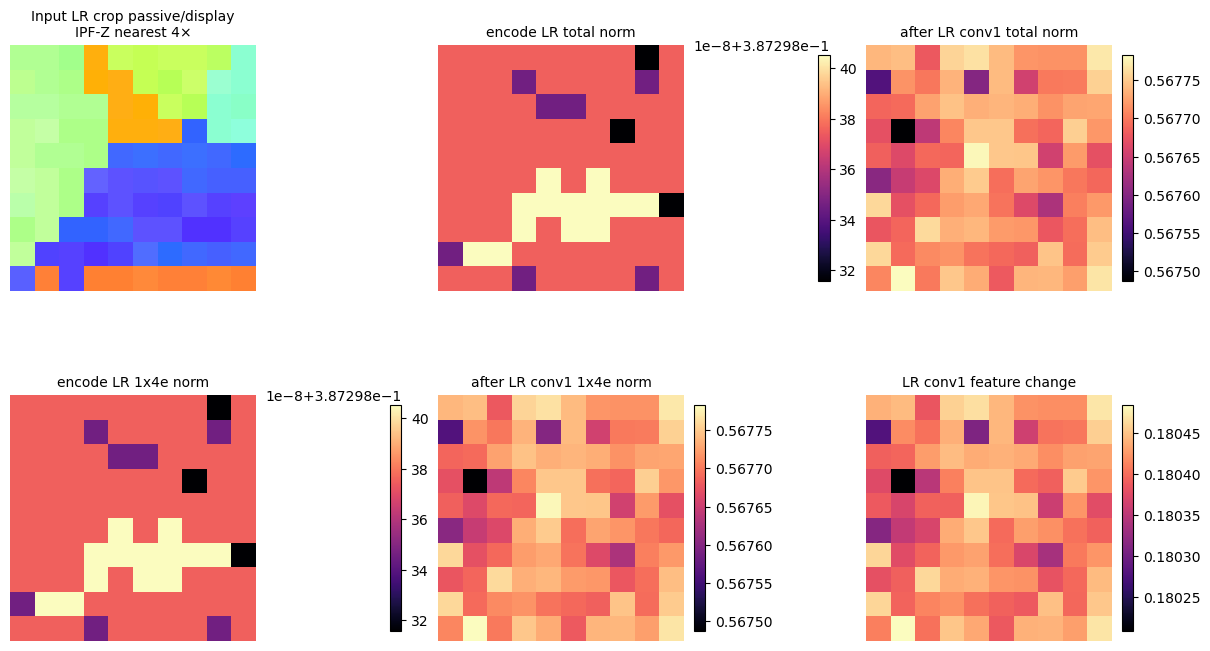

irrep norm blocks: ['1x4e']
saved: /data/home/umang/Materials/Reynolds-QSR_paper/analysis/out/ocrp_4x4_anchorless_direct_reynolds_isometric_visual_walkthrough/stage1_encode_lr_conv_active.png


In [15]:
def image_from_flat_feature(feat: torch.Tensor, shape: tuple[int, int]) -> np.ndarray:
    x = feat.detach().float().cpu()
    if x.dim() == 3:
        x = x[0]
    h, w = shape
    return x.reshape(h, w, -1).numpy()


def feature_norm_map(feat: torch.Tensor, shape: tuple[int, int]) -> np.ndarray:
    img = image_from_flat_feature(feat, shape)
    return np.linalg.norm(img, axis=-1)


def irrep_block_norm_maps(feat: torch.Tensor, shape: tuple[int, int], irreps) -> dict[str, np.ndarray]:
    img = image_from_flat_feature(feat, shape)
    out = {}
    for sl, mul_ir in zip(irreps.slices(), irreps):
        out[str(mul_ir)] = np.linalg.norm(img[..., sl.start:sl.stop], axis=-1)
    return out

enc_norms = irrep_block_norm_maps(aux["feat_lr_encode"], lr_shape_crop, model.irreps_feat)
pre_norms = irrep_block_norm_maps(aux["feat_lr_pre_ocrp"], lr_shape_crop, model.irreps_feat)
if set(enc_norms) != {EXPECTED_IRREPS} or set(pre_norms) != {EXPECTED_IRREPS}:
    raise RuntimeError(
        f"Expected only {EXPECTED_IRREPS} block, got encode={list(enc_norms)} pre_ocrp={list(pre_norms)}"
    )

fig, ax = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)
show_rgb(ax[0, 0], render_ipf_rgb(nearest_upsample_np(lr_crop_passive, 4), SYM_CLASS, ref_dir=IPF_REF_DIR), f"Input LR crop passive/display\nIPF-{IPF_REF_DIR} nearest 4×")
show_scalar(ax[0, 1], feature_norm_map(aux["feat_lr_encode"], lr_shape_crop), "encode LR total norm")
show_scalar(ax[0, 2], feature_norm_map(aux["feat_lr_pre_ocrp"], lr_shape_crop), "after LR conv1 total norm")
show_scalar(ax[1, 0], enc_norms[EXPECTED_IRREPS], f"encode LR {EXPECTED_IRREPS} norm")
show_scalar(ax[1, 1], pre_norms[EXPECTED_IRREPS], f"after LR conv1 {EXPECTED_IRREPS} norm")
show_scalar(ax[1, 2], np.linalg.norm(image_from_flat_feature(aux["feat_lr_pre_ocrp"] - aux["feat_lr_encode"], lr_shape_crop), axis=-1), "LR conv1 feature change")
fig.savefig(OUT_DIR / "stage1_encode_lr_conv_active.png", dpi=200, bbox_inches="tight")
plt.show()
print("irrep norm blocks:", list(enc_norms))
print("saved:", OUT_DIR / "stage1_encode_lr_conv_active.png")


## One-Glance Feature Flow

This strip shows the main spatial feature norm at every major stage. It is the easiest way to see where the model changes the field: LR encoding, LR convolution, raw OCRP HR assembly, HR conv refinement, and final HR feature output.


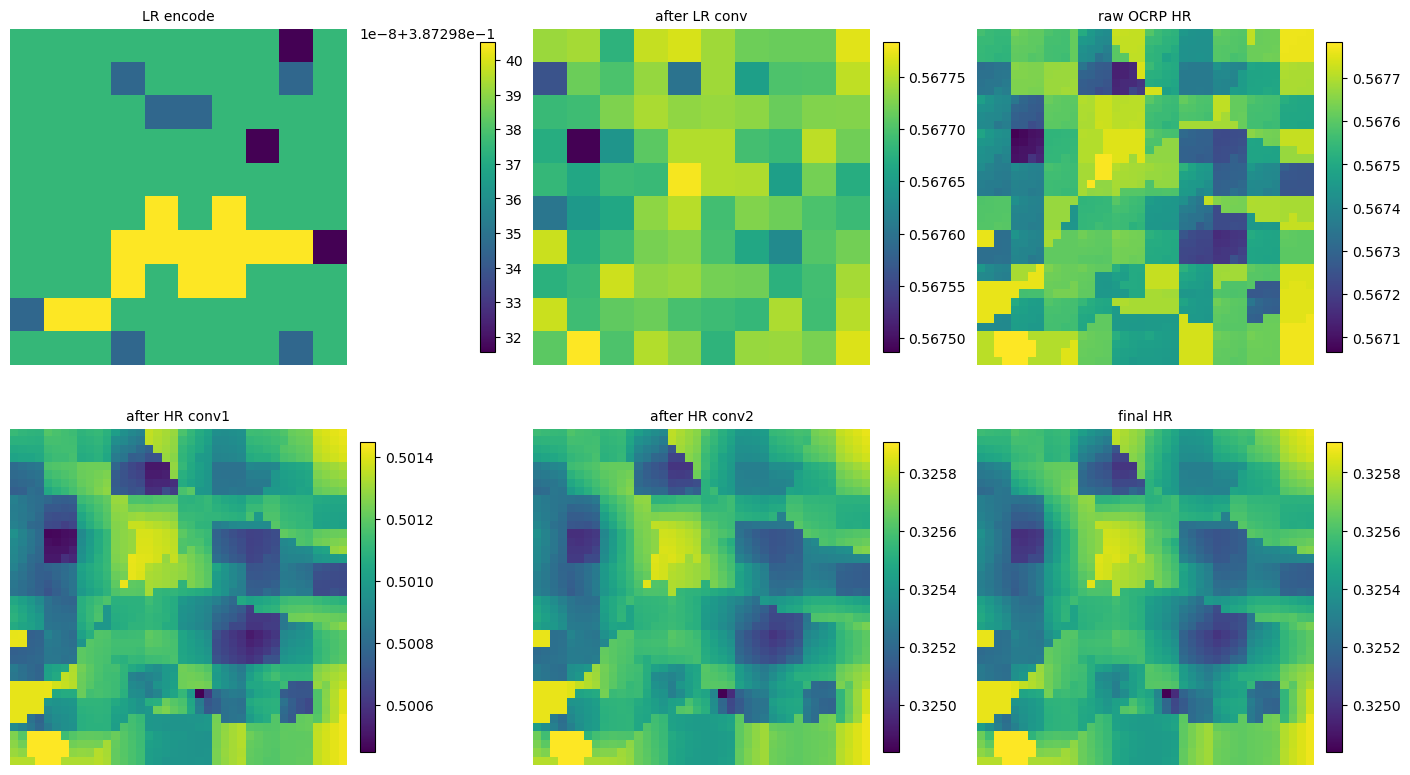

saved: /data/home/umang/Materials/Reynolds-QSR_paper/analysis/out/ocrp_4x4_anchorless_direct_reynolds_isometric_visual_walkthrough/04_feature_flow_norm_strip.png


In [16]:
stage_strip = [
    ("LR encode", aux["feat_lr_encode"], lr_shape_crop),
    ("after LR conv", aux["feat_lr_pre_ocrp"], lr_shape_crop),
    ("raw OCRP HR", aux["feat_hr_raw_ocrp"], hr_shape_crop),
    ("after HR conv1", aux["feat_hr_post_hr_conv1"], hr_shape_crop),
    ("after HR conv2", aux["feat_hr_post_hr_conv2"], hr_shape_crop),
    ("final HR", aux["feat_hr_post_hr_conv"], hr_shape_crop),
]
fig, ax = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
for axis, (title, feat, shape) in zip(ax.ravel(), stage_strip):
    show_scalar(axis, feature_norm_map(feat, shape), title, cmap="viridis")
fig.savefig(OUT_DIR / "04_feature_flow_norm_strip.png", dpi=180, bbox_inches="tight")
plt.show()
print("saved:", OUT_DIR / "04_feature_flow_norm_strip.png")


# Stage 2 — LR Masked Equivariant Convolution

`conv_lr1` is a cosine-masked equivariant spatial convolution on the `1x4e` LR feature map.

For each LR pixel, the layer extracts a local feature patch, compares neighbor features to the center by cosine similarity, suppresses neighbors below the configured threshold, renormalizes the learned spatial weights over the surviving support, and applies the equivariant convolution with the residual branch.

The intended behavior is local smoothing within similar-orientation regions while reducing mixing across strong orientation jumps.


conv_lr1 kernel_size: 5
conv_lr1 cosine threshold: 0.97
conv_lr1 soft mask: False
conv_lr1 residual: True weight: 1.0
conv_lr1 learned base weights:
[[0.01958 0.02078 0.02198 0.02059 0.01938]
 [0.02004 0.02215 0.0254  0.02214 0.02006]
 [0.02101 0.02511 0.4816  0.0267  0.02157]
 [0.01981 0.02173 0.02619 0.02221 0.02011]
 [0.0192  0.02039 0.02208 0.02071 0.0195 ]]


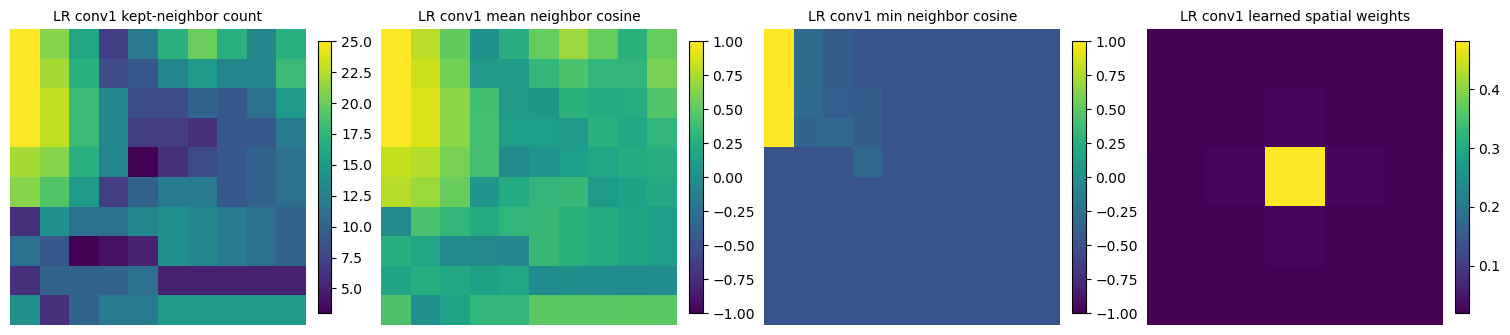

saved: /data/home/umang/Materials/Reynolds-QSR_paper/analysis/out/ocrp_4x4_anchorless_direct_reynolds_isometric_visual_walkthrough/stage2_lr_conv_mask_diagnostics.png


In [17]:
def conv_mask_diagnostics(layer, features: torch.Tensor, img_shape: tuple[int, int]) -> dict[str, np.ndarray]:
    with torch.no_grad():
        feat = features if features.dim() == 3 else features.unsqueeze(0)
        bsz, n, cdim = feat.shape
        h, w = img_shape
        feat_img = feat.reshape(bsz, h, w, cdim).permute(0, 3, 1, 2).contiguous()
        patches = layer._extract_patches(feat_img)
        center = feat_img.unsqueeze(-1).unsqueeze(-1)
        dot = (patches * center).sum(dim=1)
        patch_norm = patches.pow(2).sum(dim=1).clamp_min(layer.eps).sqrt()
        center_norm = feat_img.pow(2).sum(dim=1).clamp_min(layer.eps).sqrt().unsqueeze(-1).unsqueeze(-1)
        cosine = (dot / (patch_norm * center_norm).clamp_min(layer.eps)).clamp(-1.0, 1.0)
        masked_w = layer._masked_spatial_weights(cosine)
        support = (masked_w > 0).sum(dim=(-1, -2)).float()
        denom = masked_w.sum(dim=(-1, -2)).clamp_min(layer.eps)
        prob = masked_w / denom.unsqueeze(-1).unsqueeze(-1)
        entropy = -(prob.clamp_min(1e-12) * prob.clamp_min(1e-12).log()).sum(dim=(-1, -2))
        mean_cos = cosine.mean(dim=(-1, -2))
        min_cos = cosine.amin(dim=(-1, -2))
    return {
        "support_count": support[0].detach().cpu().numpy(),
        "entropy": entropy[0].detach().cpu().numpy(),
        "mean_cosine": mean_cos[0].detach().cpu().numpy(),
        "min_cosine": min_cos[0].detach().cpu().numpy(),
        "base_weights": F.softmax(layer.spatial_logits.detach().flatten(), dim=0).reshape(layer.kernel_size, layer.kernel_size).cpu().numpy(),
    }

lr_conv_diag = conv_mask_diagnostics(model.conv_lr1, aux["feat_lr_encode"], lr_shape_crop)
print("conv_lr1 kernel_size:", model.conv_lr1.kernel_size)
print("conv_lr1 cosine threshold:", model.conv_lr1.feature_mask_cosine_threshold)
print("conv_lr1 soft mask:", model.conv_lr1.feature_mask_soft)
print("conv_lr1 residual:", model.conv_lr1.use_residual, "weight:", model.conv_lr1.residual_weight)
print("conv_lr1 learned base weights:")
print(lr_conv_diag["base_weights"])

fig, ax = plt.subplots(1, 4, figsize=(15, 4), constrained_layout=True)
show_scalar(ax[0], lr_conv_diag["support_count"], "LR conv1 kept-neighbor count", cmap="viridis")
show_scalar(ax[1], lr_conv_diag["mean_cosine"], "LR conv1 mean neighbor cosine", cmap="viridis", vmin=-1, vmax=1)
show_scalar(ax[2], lr_conv_diag["min_cosine"], "LR conv1 min neighbor cosine", cmap="viridis", vmin=-1, vmax=1)
show_scalar(ax[3], lr_conv_diag["base_weights"], "LR conv1 learned spatial weights", cmap="viridis")
fig.savefig(OUT_DIR / "stage2_lr_conv_mask_diagnostics.png", dpi=200, bbox_inches="tight")
plt.show()
print("saved:", OUT_DIR / "stage2_lr_conv_mask_diagnostics.png")


## Effect of the LR Mask

The LR convolution should modify features mainly where local neighborhoods are coherent enough to pass the cosine mask. This view overlays the feature change with the LR and HR boundary context.


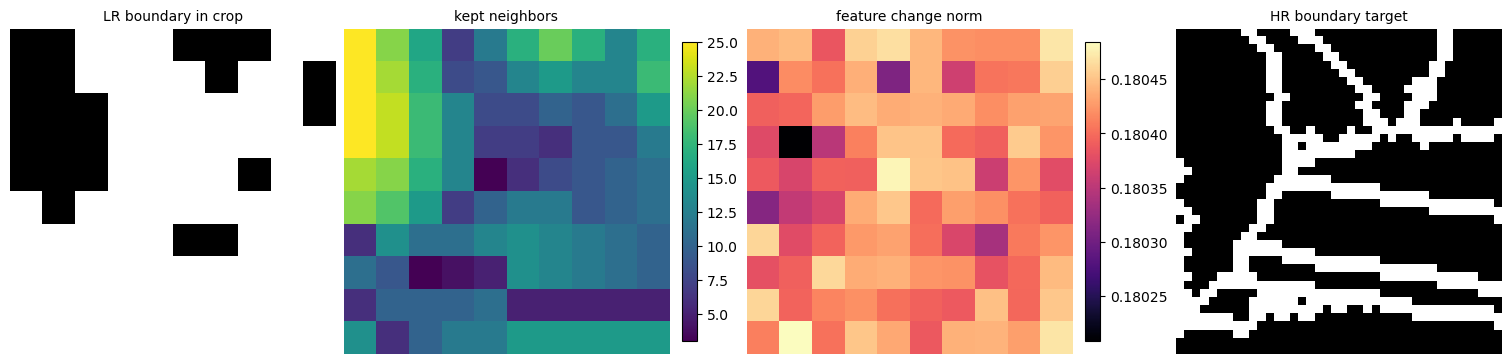

saved: /data/home/umang/Materials/Reynolds-QSR_paper/analysis/out/ocrp_4x4_anchorless_direct_reynolds_isometric_visual_walkthrough/05_lr_mask_effect_vs_boundaries.png


In [18]:
lr_feature_change = np.linalg.norm(image_from_flat_feature(aux["feat_lr_pre_ocrp"] - aux["feat_lr_encode"], lr_shape_crop), axis=-1)
lr_boundary_crop = active_boundary_mask(lr_crop_active, threshold_deg=BOUNDARY_THRESHOLD_DEG)
fig, ax = plt.subplots(1, 4, figsize=(15, 4), constrained_layout=True)
show_scalar(ax[0], lr_boundary_crop.astype(float), "LR boundary in crop", cmap="gray", colorbar=False)
show_scalar(ax[1], lr_conv_diag["support_count"], "kept neighbors", cmap="viridis")
show_scalar(ax[2], lr_feature_change, "feature change norm", cmap="magma")
show_scalar(ax[3], hr_crop_boundary.astype(float), "HR boundary target", cmap="gray", colorbar=False)
fig.savefig(OUT_DIR / "05_lr_mask_effect_vs_boundaries.png", dpi=180, bbox_inches="tight")
plt.show()
print("saved:", OUT_DIR / "05_lr_mask_effect_vs_boundaries.png")


# Stage 3 — OCRP Support Banks and Orientation Clusters

For every LR pixel, OCRP builds a `9×9` local support bank.

The main tensors are:

- `bank_q`: passive scalar-first support quaternions supplied to the checkpoint API;
- `bank_f`: corresponding `1x4e` features after `conv_lr1`;
- `cluster_ids`: connected-component labels in each local support window;
- `slot_mask` and `slot_meta`: the top orientation clusters packed into up to `K = 6` slots.

Clustering uses cubic-symmetry quaternion misorientation with the configured `cluster_threshold_deg = 2°`.


bank_q: (1, 100, 81, 4)
bank_f: (1, 100, 81, 9)
cluster_ids: (1, 100, 81)
slot_mask: (1, 100, 6, 81)
slot_meta: (1, 100, 6, 11)
selected diagnostic LR center within crop: (1, 4) global LR: (42, 4)
valid slots at selected center: [1. 1. 1. 1. 1. 1.]
slot masses at selected center: [0.37037 0.30864 0.1358  0.09877 0.04938 0.03704]


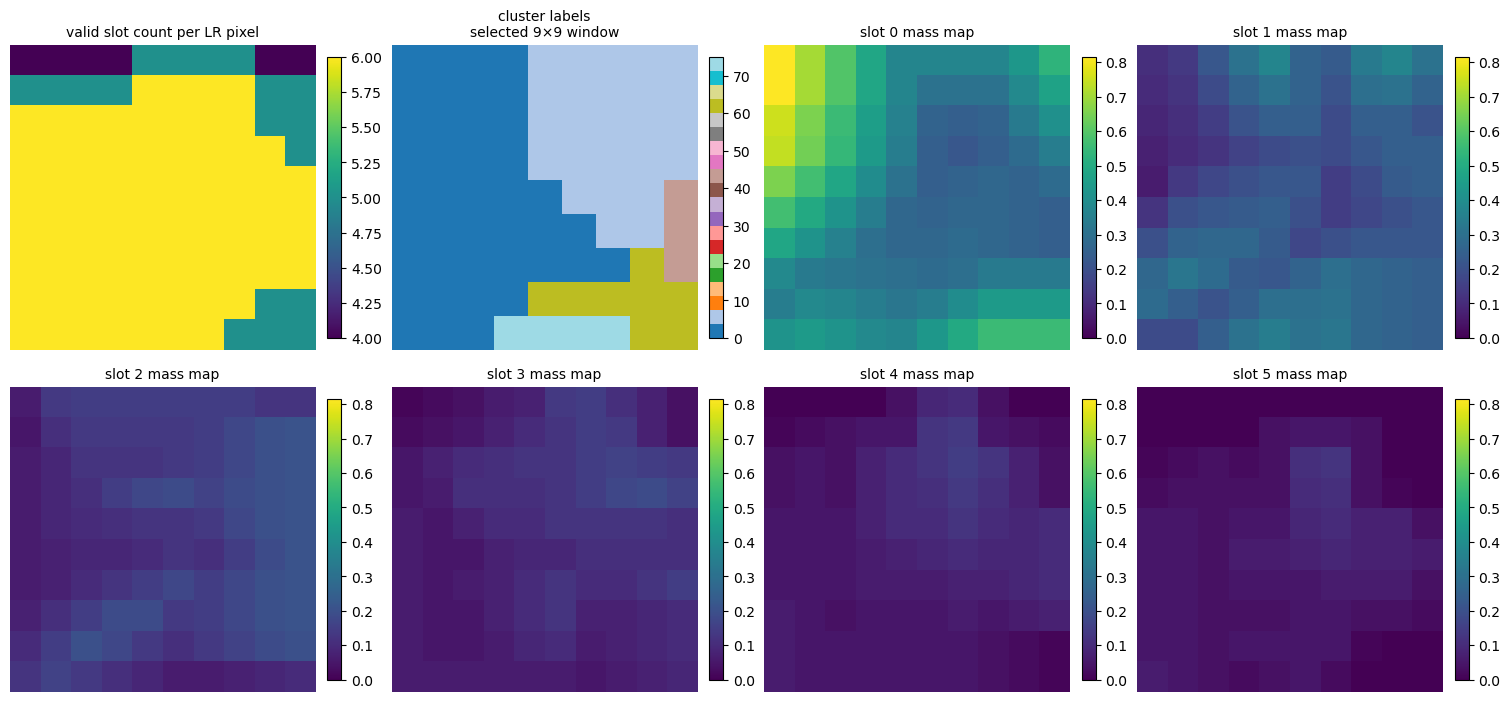

saved: /data/home/umang/Materials/Reynolds-QSR_paper/analysis/out/ocrp_4x4_anchorless_direct_reynolds_isometric_visual_walkthrough/stage3_ocrp_clusters_slots.png


In [19]:
slot_valid_count = aux["slot_valid"].detach().float().cpu().numpy()[0].sum(axis=-1).reshape(LR_CROP_SIZE, LR_CROP_SIZE)
slot_mass = aux["slot_meta"].detach().float().cpu().numpy()[0, :, :, 7].reshape(LR_CROP_SIZE, LR_CROP_SIZE, model.ocrp.kmax_slots)
cluster_ids_np = aux["cluster_ids"].detach().cpu().numpy()[0].reshape(LR_CROP_SIZE, LR_CROP_SIZE, model.ocrp.window_size, model.ocrp.window_size)

# Choose an LR center inside the crop that has the richest slot structure.
slot_rich = np.unravel_index(np.argmax(slot_valid_count), slot_valid_count.shape)
CENTER_LR_R, CENTER_LR_C = int(slot_rich[0]), int(slot_rich[1])
CENTER_N = CENTER_LR_R * LR_CROP_SIZE + CENTER_LR_C

print("bank_q:", tuple(aux["bank_q"].shape))
print("bank_f:", tuple(aux["bank_f"].shape))
print("cluster_ids:", tuple(aux["cluster_ids"].shape))
print("slot_mask:", tuple(aux["slot_mask"].shape))
print("slot_meta:", tuple(aux["slot_meta"].shape))
print("selected diagnostic LR center within crop:", (CENTER_LR_R, CENTER_LR_C), "global LR:", (LR_R0 + CENTER_LR_R, LR_C0 + CENTER_LR_C))
print("valid slots at selected center:", aux["slot_valid"][0, CENTER_N].detach().cpu().numpy())
print("slot masses at selected center:", slot_mass[CENTER_LR_R, CENTER_LR_C])

fig, ax = plt.subplots(2, 4, figsize=(15, 7), constrained_layout=True)
show_scalar(ax[0, 0], slot_valid_count, "valid slot count per LR pixel", cmap="viridis")
show_scalar(ax[0, 1], cluster_ids_np[CENTER_LR_R, CENTER_LR_C], "cluster labels\nselected 9×9 window", cmap="tab20", colorbar=True)
for k in range(6):
    rr = 0 if k < 2 else 1
    cc = k + 2 if k < 2 else k - 2
    show_scalar(ax[rr, cc], slot_mass[..., k], f"slot {k} mass map", cmap="viridis", vmin=0, vmax=max(1e-6, slot_mass.max()))
fig.savefig(OUT_DIR / "stage3_ocrp_clusters_slots.png", dpi=200, bbox_inches="tight")
plt.show()
print("saved:", OUT_DIR / "stage3_ocrp_clusters_slots.png")


## What One OCRP Window Contains

The selected LR center is the pixel with the richest slot structure in the crop. This panel shows its local support window, the cluster labels assigned inside that window, and the slot masses used downstream by the router and proposal network.


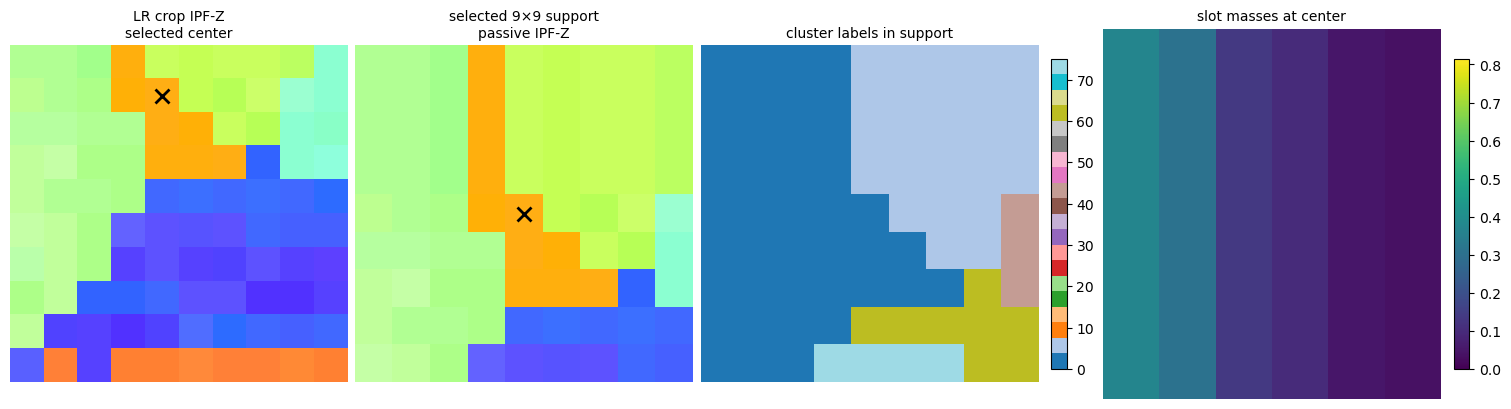

saved: /data/home/umang/Materials/Reynolds-QSR_paper/analysis/out/ocrp_4x4_anchorless_direct_reynolds_isometric_visual_walkthrough/06_selected_ocrp_support_window.png


In [20]:
bank_q_selected = aux["bank_q"].detach().cpu().numpy()[0, CENTER_N].reshape(model.ocrp.window_size, model.ocrp.window_size, 4)
center_support = model.ocrp.window_size // 2
support_ipf = render_ipf_rgb(bank_q_selected, SYM_CLASS, ref_dir=IPF_REF_DIR)
fig, ax = plt.subplots(1, 4, figsize=(15, 4), constrained_layout=True)
show_rgb(ax[0], render_ipf_rgb(lr_crop_passive, SYM_CLASS, ref_dir=IPF_REF_DIR), f"LR crop IPF-{IPF_REF_DIR}\nselected center")
ax[0].plot(CENTER_LR_C, CENTER_LR_R, marker="x", color="black", markersize=10, markeredgewidth=2)
show_rgb(ax[1], support_ipf, f"selected 9×9 support\npassive IPF-{IPF_REF_DIR}")
ax[1].plot(center_support, center_support, marker="x", color="black", markersize=10, markeredgewidth=2)
show_scalar(ax[2], cluster_ids_np[CENTER_LR_R, CENTER_LR_C], "cluster labels in support", cmap="tab20", colorbar=True)
show_scalar(ax[3], slot_mass[CENTER_LR_R, CENTER_LR_C][None, :], "slot masses at center", cmap="viridis", vmin=0, vmax=max(1e-6, slot_mass.max()))
ax[3].set_aspect("auto")
fig.savefig(OUT_DIR / "06_selected_ocrp_support_window.png", dpi=180, bbox_inches="tight")
plt.show()
print("saved:", OUT_DIR / "06_selected_ocrp_support_window.png")


# Stage 4 — Patch Router Ownership

For each LR pixel, OCRP predicts a complete `4×4` HR patch. The router assigns each of the 16 HR patch tokens to one of the local orientation slots.

```text
router_logits: (B, N_LR, 16 HR tokens, K slots)
owner_idx:     (B, N_LR, 16 HR tokens)
```

`owner_idx` is the hard selected slot. The maps below show whether ownership is spatially coherent or fragmented.


router_logits: (1, 100, 16, 6)
owner_idx: (1, 100, 16)
selected center owner 4×4 patch:
[[2 2 2 1]
 [2 2 2 1]
 [2 2 2 2]
 [2 2 2 2]]


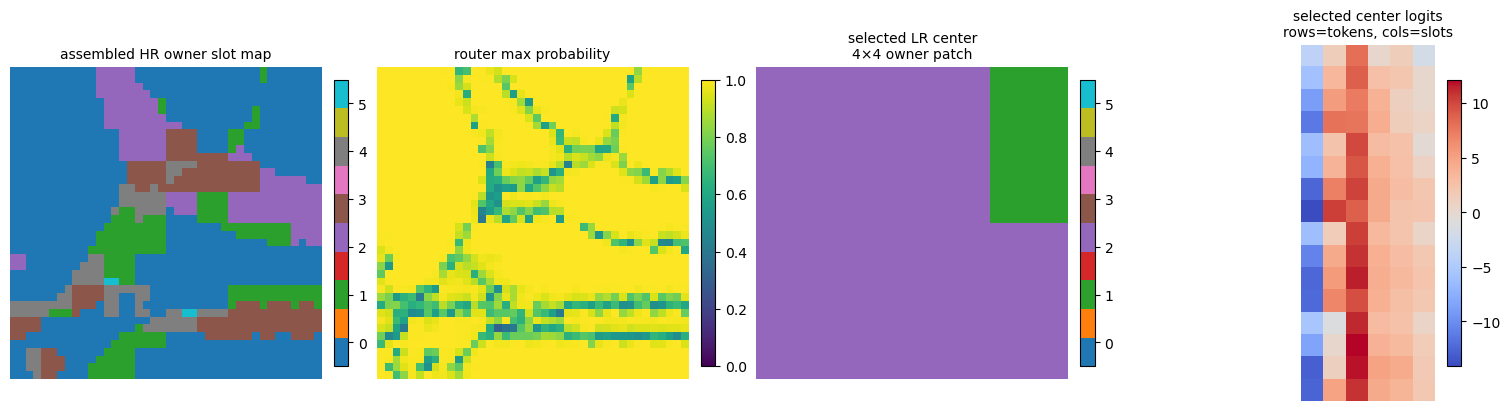

saved: /data/home/umang/Materials/Reynolds-QSR_paper/analysis/out/ocrp_4x4_anchorless_direct_reynolds_isometric_visual_walkthrough/stage4_router_ownership.png


In [21]:
def assemble_patch_scalar(values: np.ndarray, lr_h: int, lr_w: int, r_h: int = 4, r_w: int = 4) -> np.ndarray:
    # values: (N_lr, T) where T = r_h*r_w
    return values.reshape(lr_h, lr_w, r_h, r_w).transpose(0, 2, 1, 3).reshape(lr_h * r_h, lr_w * r_w)

owner_idx_np = aux["owner_idx"].detach().cpu().numpy()[0]
owner_hr_map = assemble_patch_scalar(owner_idx_np, LR_CROP_SIZE, LR_CROP_SIZE, 4, 4)
router_logits_np = aux["router_logits"].detach().float().cpu().numpy()[0]
router_conf_np = np.max(torch.softmax(aux["router_logits"].detach().float(), dim=-1).cpu().numpy()[0], axis=-1)
router_conf_hr_map = assemble_patch_scalar(router_conf_np, LR_CROP_SIZE, LR_CROP_SIZE, 4, 4)

selected_owner_patch = owner_idx_np[CENTER_N].reshape(4, 4)
selected_logits_patch = router_logits_np[CENTER_N]

print("router_logits:", tuple(aux["router_logits"].shape))
print("owner_idx:", tuple(aux["owner_idx"].shape))
print("selected center owner 4×4 patch:")
print(selected_owner_patch)

fig, ax = plt.subplots(1, 4, figsize=(15, 4), constrained_layout=True)
show_scalar(ax[0], owner_hr_map, "assembled HR owner slot map", cmap="tab10", vmin=-0.5, vmax=5.5)
show_scalar(ax[1], router_conf_hr_map, "router max probability", cmap="viridis", vmin=0, vmax=1)
show_scalar(ax[2], selected_owner_patch, "selected LR center\n4×4 owner patch", cmap="tab10", vmin=-0.5, vmax=5.5)
show_scalar(ax[3], selected_logits_patch, "selected center logits\nrows=tokens, cols=slots", cmap="coolwarm")
fig.savefig(OUT_DIR / "stage4_router_ownership.png", dpi=200, bbox_inches="tight")
plt.show()
print("saved:", OUT_DIR / "stage4_router_ownership.png")


## Router Effect in HR Space

The router turns per-slot proposals into a single HR patch by choosing an owner slot for each HR token. Compare the owner map with confidence and the HR boundary mask: coherent ownership should line up with meaningful local structure, not random checkerboarding.


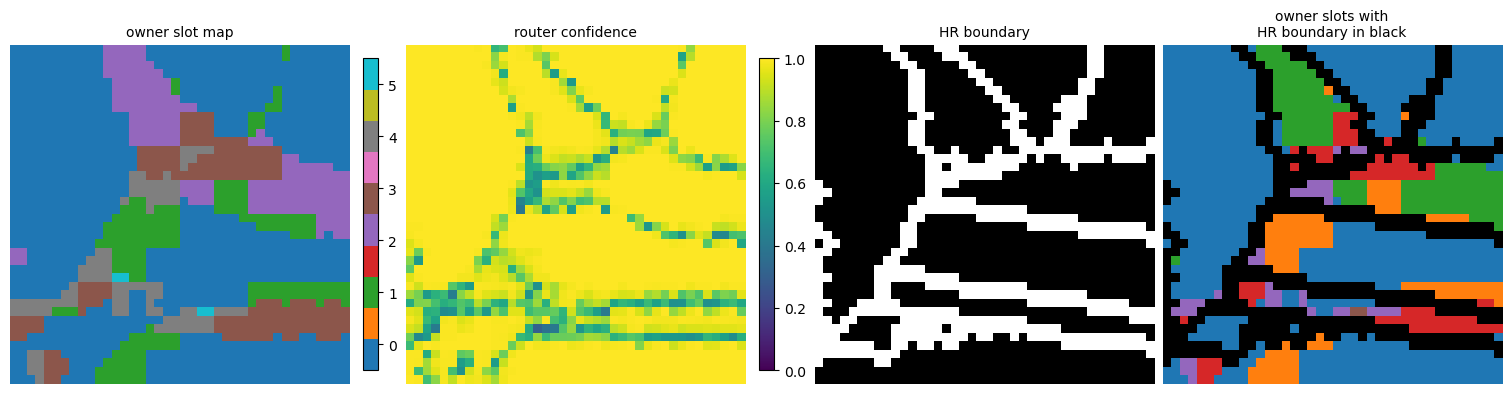

saved: /data/home/umang/Materials/Reynolds-QSR_paper/analysis/out/ocrp_4x4_anchorless_direct_reynolds_isometric_visual_walkthrough/07_router_owner_boundary_context.png


In [22]:
owner_overlay_rgb = np.zeros((*owner_hr_map.shape, 3), dtype=np.float32)
owner_colors = plt.get_cmap("tab10")((owner_hr_map.astype(int) % 10) / 9.0)[..., :3]
owner_overlay_rgb[:] = owner_colors
owner_overlay_rgb[hr_crop_boundary] = 0.0
fig, ax = plt.subplots(1, 4, figsize=(15, 4), constrained_layout=True)
show_scalar(ax[0], owner_hr_map, "owner slot map", cmap="tab10", vmin=-0.5, vmax=5.5)
show_scalar(ax[1], router_conf_hr_map, "router confidence", cmap="viridis", vmin=0, vmax=1)
show_scalar(ax[2], hr_crop_boundary.astype(float), "HR boundary", cmap="gray", colorbar=False)
show_rgb(ax[3], owner_overlay_rgb, "owner slots with\nHR boundary in black")
fig.savefig(OUT_DIR / "07_router_owner_boundary_context.png", dpi=180, bbox_inches="tight")
plt.show()
print("saved:", OUT_DIR / "07_router_owner_boundary_context.png")


# Stage 5 — Anchorless Member Cross-Attention Proposals

The anchorless path does not first collapse each slot to a single pooled anchor. Instead, each HR token attends directly to the LR members belonging to each candidate slot.

```text
patch_prop:  (B, N_LR, K slots, 16 HR tokens, feature_dim)
xattn_alpha: (B, N_LR, K slots, 16 HR tokens, 81 support members)
patch_out:   (B, N_LR, 16 HR tokens, feature_dim)
```

The router selects one slot proposal per HR token. The attention maps show which LR support members contributed to each slot-conditioned HR proposal.


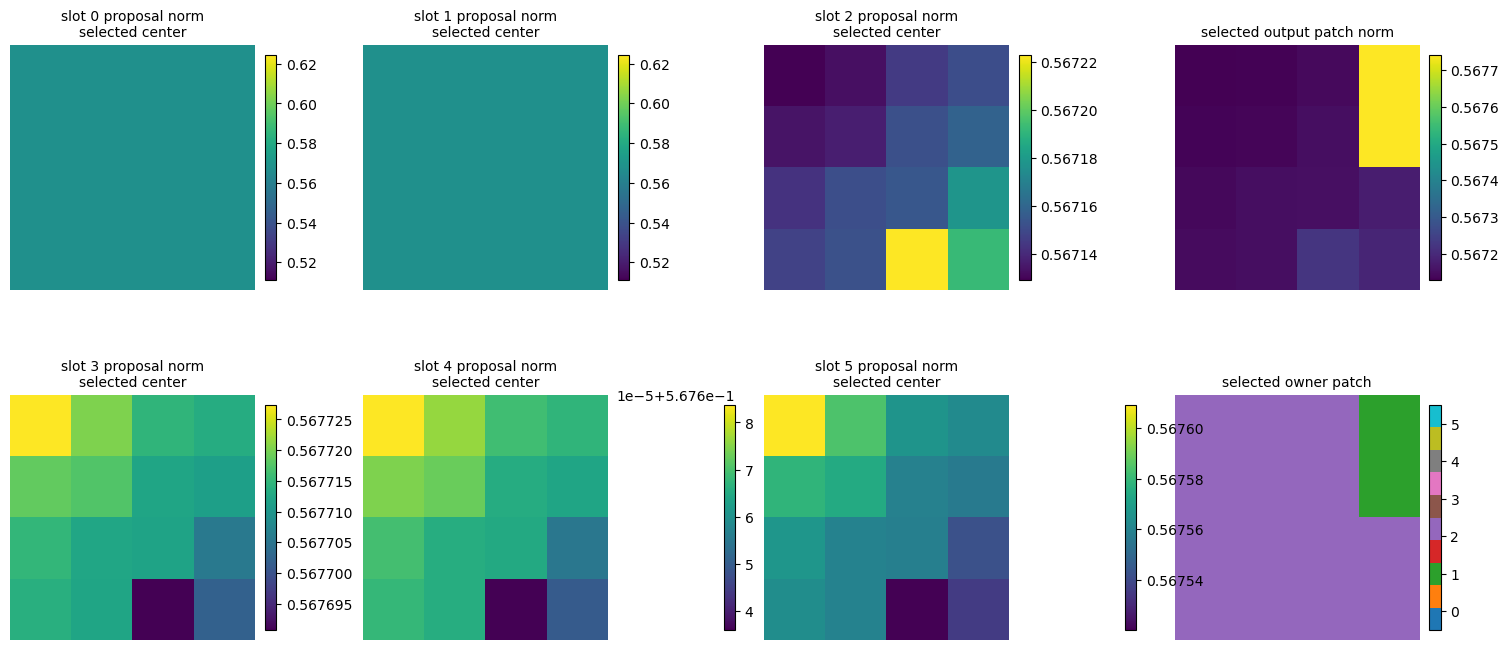

saved: /data/home/umang/Materials/Reynolds-QSR_paper/analysis/out/ocrp_4x4_anchorless_direct_reynolds_isometric_visual_walkthrough/stage5_xattn_patch_proposals.png


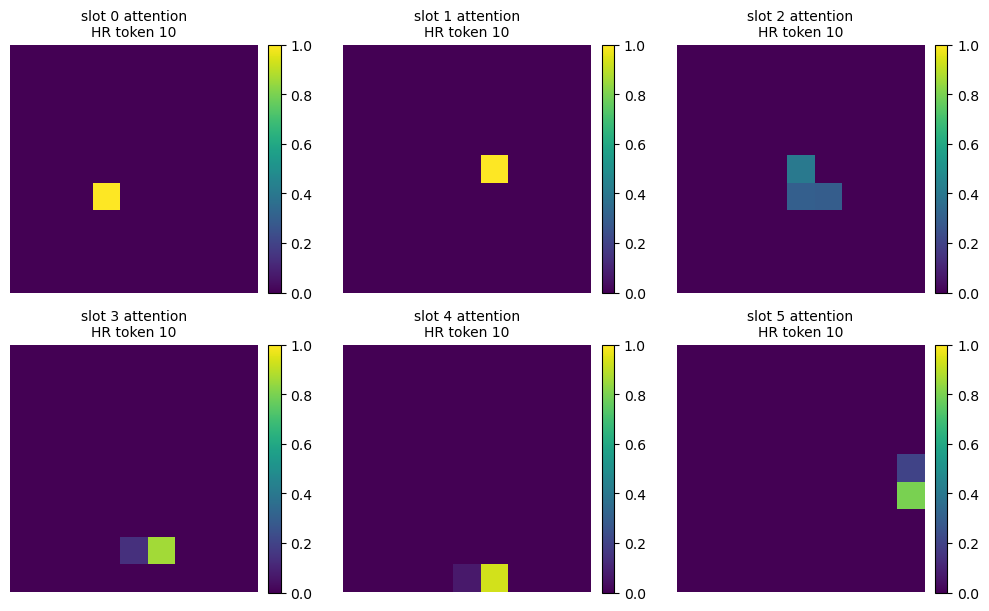

saved: /data/home/umang/Materials/Reynolds-QSR_paper/analysis/out/ocrp_4x4_anchorless_direct_reynolds_isometric_visual_walkthrough/stage5_xattn_alpha_selected_token.png


In [23]:
patch_prop_norm = aux["patch_prop"].detach().float().norm(dim=-1).cpu().numpy()[0]  # N,K,T
patch_out_norm = aux["patch_out"].detach().float().norm(dim=-1).cpu().numpy()[0]    # N,T
selected_prop_norm = patch_prop_norm[CENTER_N]  # K,T
selected_out_norm = patch_out_norm[CENTER_N].reshape(4, 4)

fig, ax = plt.subplots(2, 4, figsize=(15, 7), constrained_layout=True)
for k in range(6):
    rr, cc = divmod(k, 3)
    show_scalar(ax[rr, cc], selected_prop_norm[k].reshape(4, 4), f"slot {k} proposal norm\nselected center", cmap="viridis")
show_scalar(ax[0, 3], selected_out_norm, "selected output patch norm", cmap="viridis")
show_scalar(ax[1, 3], selected_owner_patch, "selected owner patch", cmap="tab10", vmin=-0.5, vmax=5.5)
fig.savefig(OUT_DIR / "stage5_xattn_patch_proposals.png", dpi=200, bbox_inches="tight")
plt.show()
print("saved:", OUT_DIR / "stage5_xattn_patch_proposals.png")

if aux.get("xattn_alpha") is not None:
    alpha = aux["xattn_alpha"].detach().float().cpu().numpy()[0]
    # Pick the central HR token in the 4x4 patch and display attention over 9x9 LR support members for all valid slots.
    token_id = 10  # row 2, col 2 in a 4x4 patch
    fig, axes = plt.subplots(2, 3, figsize=(10, 6), constrained_layout=True)
    axes = axes.ravel()
    for k in range(6):
        show_scalar(
            axes[k],
            alpha[CENTER_N, k, token_id].reshape(model.ocrp.window_size, model.ocrp.window_size),
            f"slot {k} attention\nHR token {token_id}",
            cmap="viridis",
            vmin=0,
            vmax=max(1e-8, alpha[CENTER_N, :, token_id].max()),
        )
    fig.savefig(OUT_DIR / "stage5_xattn_alpha_selected_token.png", dpi=200, bbox_inches="tight")
    plt.show()
    print("saved:", OUT_DIR / "stage5_xattn_alpha_selected_token.png")
else:
    print("xattn_alpha not present; rerun OCRP with return_aux=True to collect attention maps.")


## Attention for the Actually Selected Slot

For one HR token in the selected `4×4` patch, this panel shows the slot chosen by the router and the attention weights over the 9×9 LR support members. This is the most direct view of how anchorless OCRP builds a token proposal from members rather than from a pooled anchor.


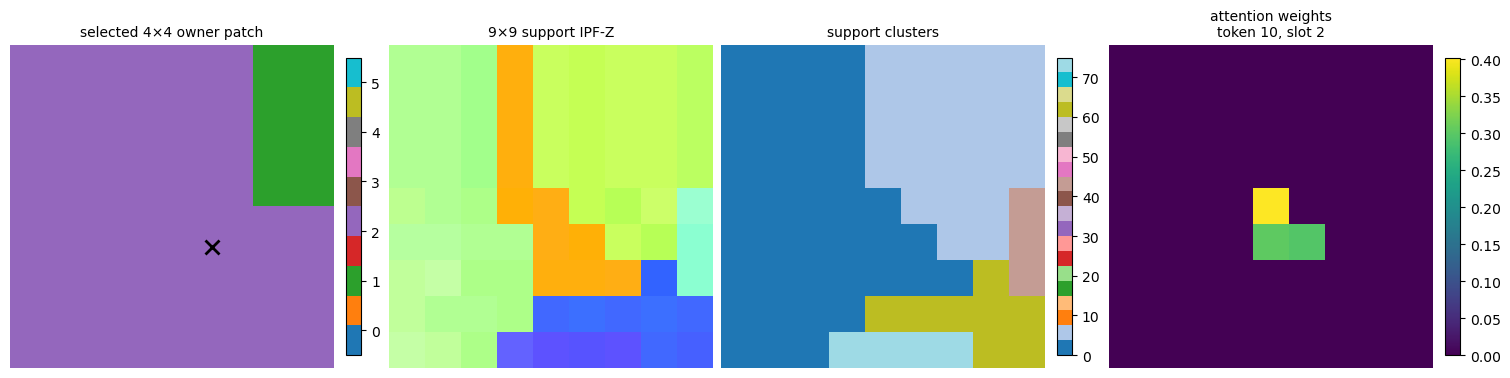

token: 10 owner slot: 2
attention sum: 0.9999999403953552 max: 0.4024224281311035
saved: /data/home/umang/Materials/Reynolds-QSR_paper/analysis/out/ocrp_4x4_anchorless_direct_reynolds_isometric_visual_walkthrough/08_selected_token_owner_attention.png


In [24]:
if aux.get("xattn_alpha") is not None:
    token_id = 10
    owner_slot = int(selected_owner_patch.reshape(-1)[token_id])
    alpha = aux["xattn_alpha"].detach().float().cpu().numpy()[0]
    attn_owner = alpha[CENTER_N, owner_slot, token_id].reshape(model.ocrp.window_size, model.ocrp.window_size)
    support_ipf = render_ipf_rgb(bank_q_selected, SYM_CLASS, ref_dir=IPF_REF_DIR)
    fig, ax = plt.subplots(1, 4, figsize=(15, 4), constrained_layout=True)
    show_scalar(ax[0], selected_owner_patch, "selected 4×4 owner patch", cmap="tab10", vmin=-0.5, vmax=5.5)
    ax[0].plot(token_id % 4, token_id // 4, marker="x", color="black", markersize=10, markeredgewidth=2)
    show_rgb(ax[1], support_ipf, f"9×9 support IPF-{IPF_REF_DIR}")
    show_scalar(ax[2], cluster_ids_np[CENTER_LR_R, CENTER_LR_C], "support clusters", cmap="tab20")
    show_scalar(ax[3], attn_owner, f"attention weights\ntoken {token_id}, slot {owner_slot}", cmap="viridis", vmin=0, vmax=max(1e-8, float(attn_owner.max())))
    fig.savefig(OUT_DIR / "08_selected_token_owner_attention.png", dpi=180, bbox_inches="tight")
    plt.show()
    print("token:", token_id, "owner slot:", owner_slot)
    print("attention sum:", float(attn_owner.sum()), "max:", float(attn_owner.max()))
    print("saved:", OUT_DIR / "08_selected_token_owner_attention.png")
else:
    print("xattn_alpha not present; selected-slot attention visualization skipped.")


# Stage 6 — Assemble and Refine HR Features

After `patch_out`, OCRP stitches every LR pixel's `4×4` token patch into the global HR feature crop.

Then the HR masked equivariant convolutions refine the raw OCRP feature field:

```text
feat_hr_raw_ocrp
  -> conv_hr1
  -> conv_hr2
  -> feat_hr_post_hr_conv
```

The maps below localize where these HR convolutions change the `1x4e` feature field most strongly.


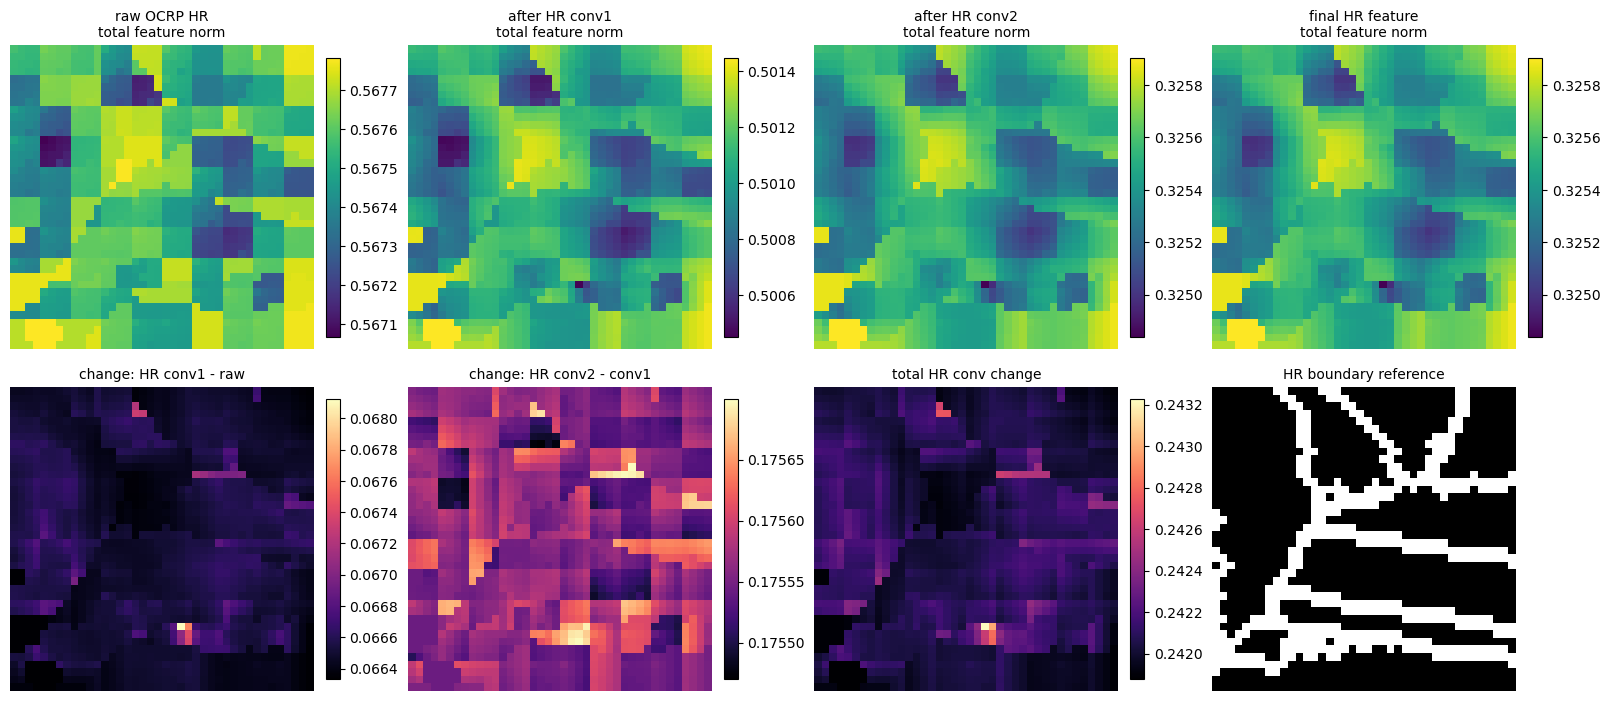

saved: /data/home/umang/Materials/Reynolds-QSR_paper/analysis/out/ocrp_4x4_anchorless_direct_reynolds_isometric_visual_walkthrough/stage6_hr_feature_refinement.png


In [25]:
hr_stage_names = [
    ("feat_hr_raw_ocrp", "raw OCRP HR"),
    ("feat_hr_post_hr_conv1", "after HR conv1"),
    ("feat_hr_post_hr_conv2", "after HR conv2"),
    ("feat_hr_post_hr_conv", "final HR feature"),
]

fig, ax = plt.subplots(2, 4, figsize=(16, 7), constrained_layout=True)
for j, (key, title) in enumerate(hr_stage_names):
    show_scalar(ax[0, j], feature_norm_map(aux[key], hr_shape_crop), f"{title}\ntotal feature norm", cmap="viridis")
show_scalar(ax[1, 0], np.linalg.norm(image_from_flat_feature(aux["feat_hr_post_hr_conv1"] - aux["feat_hr_raw_ocrp"], hr_shape_crop), axis=-1), "change: HR conv1 - raw", cmap="magma")
show_scalar(ax[1, 1], np.linalg.norm(image_from_flat_feature(aux["feat_hr_post_hr_conv2"] - aux["feat_hr_post_hr_conv1"], hr_shape_crop), axis=-1), "change: HR conv2 - conv1", cmap="magma")
show_scalar(ax[1, 2], np.linalg.norm(image_from_flat_feature(aux["feat_hr_post_hr_conv"] - aux["feat_hr_raw_ocrp"], hr_shape_crop), axis=-1), "total HR conv change", cmap="magma")
show_scalar(ax[1, 3], hr_crop_boundary.astype(float), "HR boundary reference", cmap="gray", colorbar=False)
fig.savefig(OUT_DIR / "stage6_hr_feature_refinement.png", dpi=200, bbox_inches="tight")
plt.show()
print("saved:", OUT_DIR / "stage6_hr_feature_refinement.png")


conv_hr1 kernel_size: 7 threshold: 0.97 residual: 0.3
conv_hr2 kernel_size: 7 threshold: 0.97 residual: 0.3


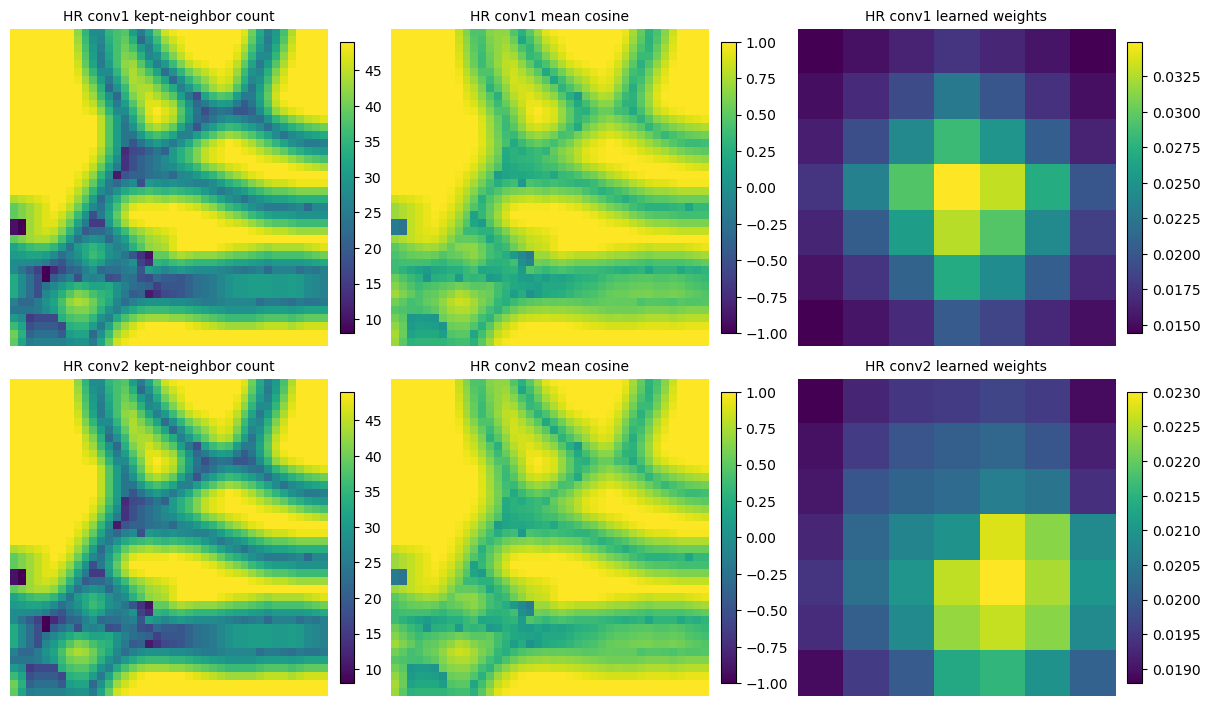

saved: /data/home/umang/Materials/Reynolds-QSR_paper/analysis/out/ocrp_4x4_anchorless_direct_reynolds_isometric_visual_walkthrough/stage6_hr_conv_mask_diagnostics.png


In [26]:
hr_conv1_diag = conv_mask_diagnostics(model.conv_hr1, aux["feat_hr_raw_ocrp"], hr_shape_crop)
hr_conv2_diag = conv_mask_diagnostics(model.conv_hr2, aux["feat_hr_post_hr_conv1"], hr_shape_crop)

print("conv_hr1 kernel_size:", model.conv_hr1.kernel_size, "threshold:", model.conv_hr1.feature_mask_cosine_threshold, "residual:", model.conv_hr1.residual_weight)
print("conv_hr2 kernel_size:", model.conv_hr2.kernel_size, "threshold:", model.conv_hr2.feature_mask_cosine_threshold, "residual:", model.conv_hr2.residual_weight)

fig, ax = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)
show_scalar(ax[0, 0], hr_conv1_diag["support_count"], "HR conv1 kept-neighbor count", cmap="viridis")
show_scalar(ax[0, 1], hr_conv1_diag["mean_cosine"], "HR conv1 mean cosine", cmap="viridis", vmin=-1, vmax=1)
show_scalar(ax[0, 2], hr_conv1_diag["base_weights"], "HR conv1 learned weights", cmap="viridis")
show_scalar(ax[1, 0], hr_conv2_diag["support_count"], "HR conv2 kept-neighbor count", cmap="viridis")
show_scalar(ax[1, 1], hr_conv2_diag["mean_cosine"], "HR conv2 mean cosine", cmap="viridis", vmin=-1, vmax=1)
show_scalar(ax[1, 2], hr_conv2_diag["base_weights"], "HR conv2 learned weights", cmap="viridis")
fig.savefig(OUT_DIR / "stage6_hr_conv_mask_diagnostics.png", dpi=200, bbox_inches="tight")
plt.show()
print("saved:", OUT_DIR / "stage6_hr_conv_mask_diagnostics.png")


## HR Refinement Effect

The HR convs operate after OCRP has assembled the raw HR feature grid. This panel separates raw assembly from HR refinement and shows whether the strongest corrections are localized near boundary structure.


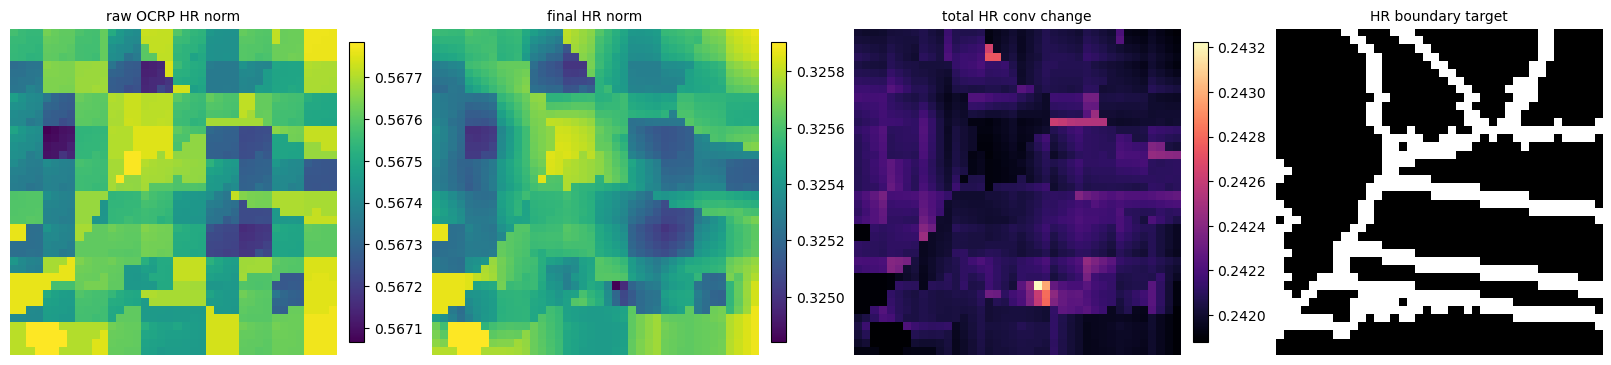

saved: /data/home/umang/Materials/Reynolds-QSR_paper/analysis/out/ocrp_4x4_anchorless_direct_reynolds_isometric_visual_walkthrough/09_hr_refinement_effect.png


In [27]:
hr_raw_norm = feature_norm_map(aux["feat_hr_raw_ocrp"], hr_shape_crop)
hr_final_norm = feature_norm_map(aux["feat_hr_post_hr_conv"], hr_shape_crop)
hr_total_change = np.linalg.norm(image_from_flat_feature(aux["feat_hr_post_hr_conv"] - aux["feat_hr_raw_ocrp"], hr_shape_crop), axis=-1)
fig, ax = plt.subplots(1, 4, figsize=(16, 4), constrained_layout=True)
show_scalar(ax[0], hr_raw_norm, "raw OCRP HR norm", cmap="viridis")
show_scalar(ax[1], hr_final_norm, "final HR norm", cmap="viridis")
show_scalar(ax[2], hr_total_change, "total HR conv change", cmap="magma")
show_scalar(ax[3], hr_crop_boundary.astype(float), "HR boundary target", cmap="gray", colorbar=False)
fig.savefig(OUT_DIR / "09_hr_refinement_effect.png", dpi=180, bbox_inches="tight")
plt.show()
print("saved:", OUT_DIR / "09_hr_refinement_effect.png")


# Stage 7 — Decode the Crop and Compare with HR

This cell decodes the final HR `1x4e` features into quaternions for the selected crop. It uses the configured cubochoric optimizing decoder through `model.decode(...)`.

The decoder performs an inner optimization over output pixels, so this cell intentionally runs on the crop rather than the full test field. Do not wrap it in `torch.no_grad()`; the decoder needs gradients internally.

Decoded quaternions are passive scalar-first in the checkpoint API convention. They are rendered directly for IPF-Z display and separately conjugated to active convention for symmetry-aware SR-vs-HR error metrics.


In [28]:
RUN_LIVE_DECODER_CROP = True

if RUN_LIVE_DECODER_CROP:
    t0 = time.time()
    # model.decode internally detaches the feature target but needs gradients for its latent quaternion optimization.
    sr_crop_api = model.decode(aux["feat_hr_post_hr_conv"].detach())
    decode_seconds = time.time() - t0
    sr_crop_passive_t = qnormalize_torch(sr_crop_api).reshape(1, HR_CROP_SIZE, HR_CROP_SIZE, 4)
    sr_crop_passive = sr_crop_passive_t[0].detach().cpu().numpy().astype(np.float32)
    sr_crop_active_t = checkpoint_output_to_active_torch(sr_crop_api).reshape(1, HR_CROP_SIZE, HR_CROP_SIZE, 4)
    sr_crop_active = sr_crop_active_t[0].detach().cpu().numpy().astype(np.float32)
    sr_hr_error_deg = misorientation_deg_active(sr_crop_active, hr_crop_active)

    print("decoded crop API output:", tuple(sr_crop_api.shape))
    print("decoded crop passive/display:", sr_crop_passive.shape)
    print("decoded crop active/metric:", sr_crop_active.shape)
    print("decode seconds:", decode_seconds)
    print("SR-vs-HR crop error degrees:")
    print("  mean:", float(np.mean(sr_hr_error_deg)))
    print("  median:", float(np.median(sr_hr_error_deg)))
    print("  p90:", float(np.percentile(sr_hr_error_deg, 90)))
    print("  max:", float(np.max(sr_hr_error_deg)))
else:
    sr_crop_passive = None
    sr_crop_active = None
    sr_hr_error_deg = None
    decode_seconds = None
    print("Live crop decoder skipped. Set RUN_LIVE_DECODER_CROP=True to run it.")


decoded crop API output: (1, 1600, 4)
decoded crop passive/display: (40, 40, 4)
decoded crop active/metric: (40, 40, 4)
decode seconds: 1.3794105052947998
SR-vs-HR crop error degrees:
  mean: 8.039460182189941
  median: 0.7952418327331543
  p90: 48.95280838012695
  max: 59.99928665161133


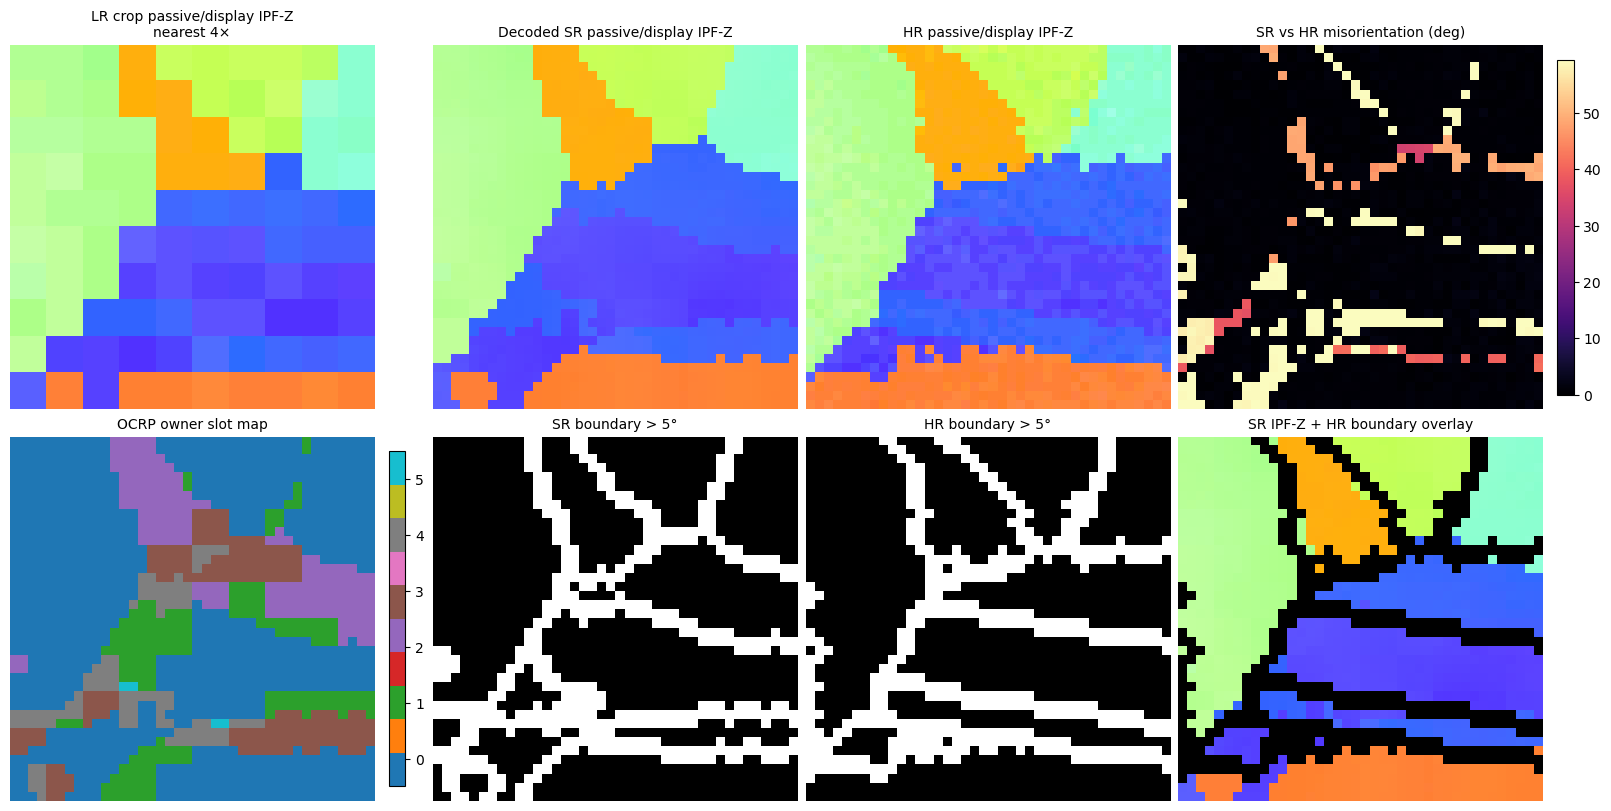

saved: /data/home/umang/Materials/Reynolds-QSR_paper/analysis/out/ocrp_4x4_anchorless_direct_reynolds_isometric_visual_walkthrough/stage7_decoded_crop_boundary_fidelity.png
boundary agreement on crop:
  TP FP FN: 264 163 171
  F1: 0.6125290023201856


In [29]:
if sr_crop_active is not None:
    sr_boundary = active_boundary_mask(sr_crop_active, threshold_deg=BOUNDARY_THRESHOLD_DEG)
    fig, ax = plt.subplots(2, 4, figsize=(16, 8), constrained_layout=True)
    show_rgb(ax[0, 0], render_ipf_rgb(nearest_upsample_np(lr_crop_passive, 4), SYM_CLASS, ref_dir=IPF_REF_DIR), f"LR crop passive/display IPF-{IPF_REF_DIR}\nnearest 4×")
    show_rgb(ax[0, 1], render_ipf_rgb(sr_crop_passive, SYM_CLASS, ref_dir=IPF_REF_DIR), f"Decoded SR passive/display IPF-{IPF_REF_DIR}")
    show_rgb(ax[0, 2], render_ipf_rgb(hr_crop_passive, SYM_CLASS, ref_dir=IPF_REF_DIR), f"HR passive/display IPF-{IPF_REF_DIR}")
    show_scalar(ax[0, 3], sr_hr_error_deg, "SR vs HR misorientation (deg)", cmap="magma", vmin=0, vmax=max(1.0, float(np.percentile(sr_hr_error_deg, 95))))

    show_scalar(ax[1, 0], owner_hr_map, "OCRP owner slot map", cmap="tab10", vmin=-0.5, vmax=5.5)
    show_scalar(ax[1, 1], sr_boundary.astype(float), "SR boundary > 5°", cmap="gray", colorbar=False)
    show_scalar(ax[1, 2], hr_crop_boundary.astype(float), "HR boundary > 5°", cmap="gray", colorbar=False)
    overlay = render_ipf_rgb(sr_crop_passive, SYM_CLASS, ref_dir=IPF_REF_DIR).copy()
    overlay[hr_crop_boundary] = np.array([0.0, 0.0, 0.0])
    show_rgb(ax[1, 3], overlay, f"SR IPF-{IPF_REF_DIR} + HR boundary overlay")
    fig.savefig(OUT_DIR / "stage7_decoded_crop_boundary_fidelity.png", dpi=220, bbox_inches="tight")
    plt.show()
    print("saved:", OUT_DIR / "stage7_decoded_crop_boundary_fidelity.png")

    # Boundary agreement score on the crop.
    tp = int(np.logical_and(sr_boundary, hr_crop_boundary).sum())
    fp = int(np.logical_and(sr_boundary, ~hr_crop_boundary).sum())
    fn = int(np.logical_and(~sr_boundary, hr_crop_boundary).sum())
    f1 = 2 * tp / max(1, 2 * tp + fp + fn)
    print("boundary agreement on crop:")
    print("  TP FP FN:", tp, fp, fn)
    print("  F1:", f1)


# Stage 8 — Feature-Target Check Against Encoded HR

The decoded quaternion image is useful for visual inspection, but the training signal is in feature space. This cell compares the final predicted HR features against the HR crop encoded by the same direct-Reynolds-isometric encoder.

Both target and prediction live in the same `1x4e` representation. The feature error map is therefore the cleanest pre-decoder diagnostic of what the network learned, while the decoded misorientation map shows the downstream orientation-level effect.


encoded HR target: (1, 1600, 9)
feature MSE: 0.005658630281686783
feature error norm mean: 0.13474738597869873
feature error norm p90: 0.5742214918136597


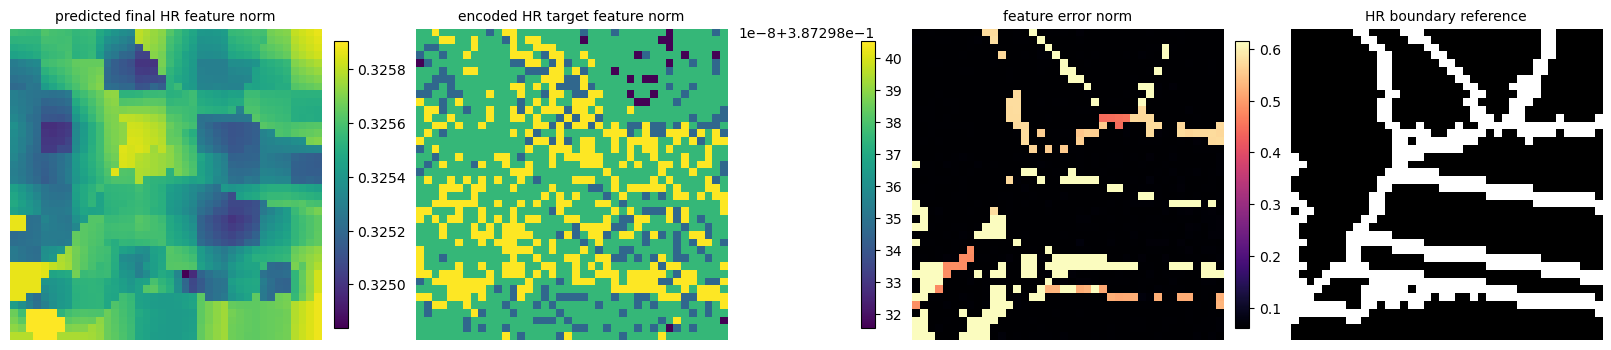

saved: /data/home/umang/Materials/Reynolds-QSR_paper/analysis/out/ocrp_4x4_anchorless_direct_reynolds_isometric_visual_walkthrough/stage8_feature_target_error.png


In [30]:
q_hr_crop_active_t = torch.from_numpy(hr_crop_active).to(device=DEVICE, dtype=DTYPE).reshape(1, -1, 4)
q_hr_crop_api_t = torch.from_numpy(hr_crop_passive).to(device=DEVICE, dtype=DTYPE).reshape(1, -1, 4)
with torch.no_grad():
    feat_hr_target_flat = model.encode(q_hr_crop_api_t.reshape(-1, 4))
    feat_hr_target = feat_hr_target_flat.reshape(1, -1, feat_hr_target_flat.shape[-1])
    feat_err = aux["feat_hr_post_hr_conv"] - feat_hr_target

feat_err_norm = feature_norm_map(feat_err, hr_shape_crop)
feat_tgt_norm = feature_norm_map(feat_hr_target, hr_shape_crop)
feat_pred_norm = feature_norm_map(aux["feat_hr_post_hr_conv"], hr_shape_crop)

print("encoded HR target:", tuple(feat_hr_target.shape))
print("feature MSE:", float((feat_err.detach().float() ** 2).mean().cpu()))
print("feature error norm mean:", float(feat_err_norm.mean()))
print("feature error norm p90:", float(np.percentile(feat_err_norm, 90)))

fig, ax = plt.subplots(1, 4, figsize=(16, 4), constrained_layout=True)
show_scalar(ax[0], feat_pred_norm, "predicted final HR feature norm", cmap="viridis")
show_scalar(ax[1], feat_tgt_norm, "encoded HR target feature norm", cmap="viridis")
show_scalar(ax[2], feat_err_norm, "feature error norm", cmap="magma")
show_scalar(ax[3], hr_crop_boundary.astype(float), "HR boundary reference", cmap="gray", colorbar=False)
fig.savefig(OUT_DIR / "stage8_feature_target_error.png", dpi=220, bbox_inches="tight")
plt.show()
print("saved:", OUT_DIR / "stage8_feature_target_error.png")


## Final Walkthrough Dashboard

This final panel ties the stages together: input, target, decoded output, routing, feature refinement, and representation-space error. It is intended as the quickest qualitative read of how this direct-Reynolds `1x4e` model behaves on the selected Test crop.


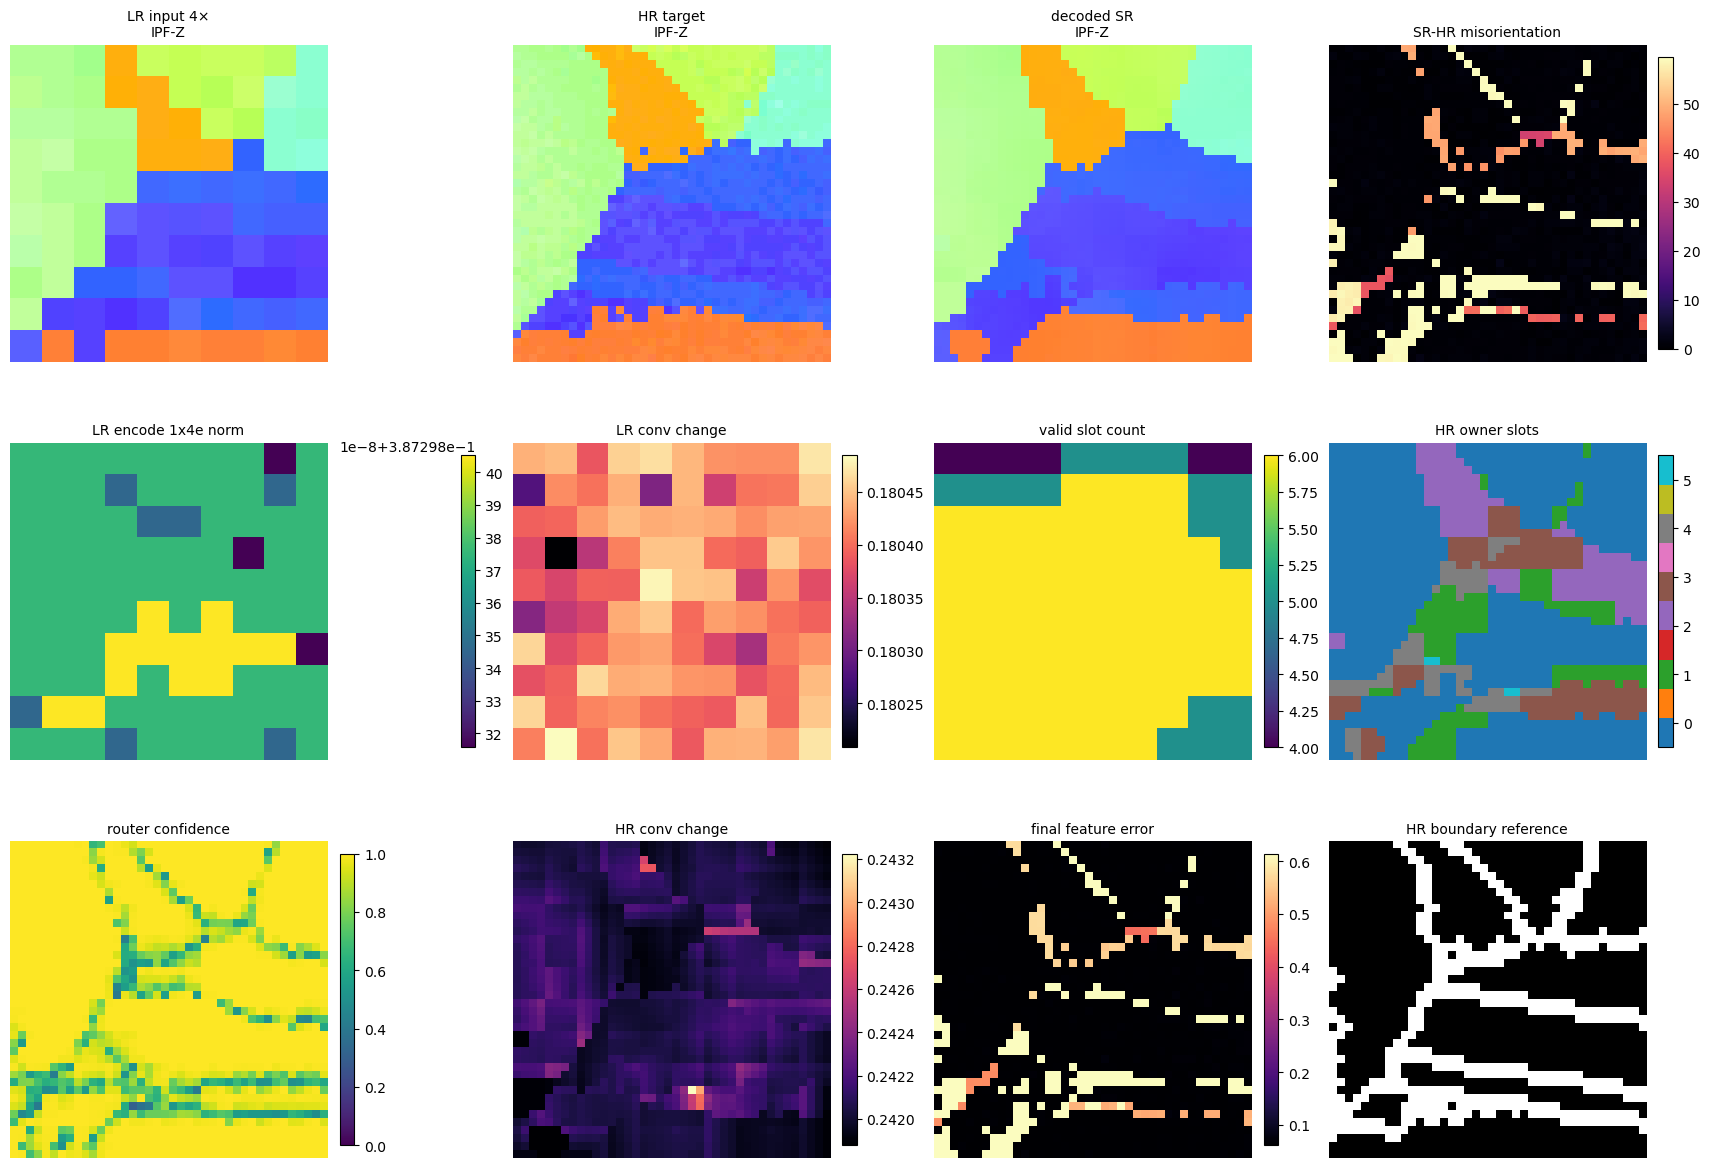

saved: /data/home/umang/Materials/Reynolds-QSR_paper/analysis/out/ocrp_4x4_anchorless_direct_reynolds_isometric_visual_walkthrough/10_final_visual_walkthrough_dashboard.png


In [31]:
fig, ax = plt.subplots(3, 4, figsize=(17, 12), constrained_layout=True)
show_rgb(ax[0, 0], render_ipf_rgb(nearest_upsample_np(lr_crop_passive, 4), SYM_CLASS, ref_dir=IPF_REF_DIR), f"LR input 4×\nIPF-{IPF_REF_DIR}")
show_rgb(ax[0, 1], render_ipf_rgb(hr_crop_passive, SYM_CLASS, ref_dir=IPF_REF_DIR), f"HR target\nIPF-{IPF_REF_DIR}")
if sr_crop_passive is not None:
    show_rgb(ax[0, 2], render_ipf_rgb(sr_crop_passive, SYM_CLASS, ref_dir=IPF_REF_DIR), f"decoded SR\nIPF-{IPF_REF_DIR}")
    show_scalar(ax[0, 3], sr_hr_error_deg, "SR-HR misorientation", cmap="magma", vmin=0, vmax=max(1.0, float(np.percentile(sr_hr_error_deg, 95))))
else:
    ax[0, 2].axis("off")
    ax[0, 2].set_title("decoded SR skipped")
    ax[0, 3].axis("off")
    ax[0, 3].set_title("misorientation skipped")
show_scalar(ax[1, 0], enc_norms[EXPECTED_IRREPS], "LR encode 1x4e norm", cmap="viridis")
show_scalar(ax[1, 1], lr_feature_change, "LR conv change", cmap="magma")
show_scalar(ax[1, 2], slot_valid_count, "valid slot count", cmap="viridis")
show_scalar(ax[1, 3], owner_hr_map, "HR owner slots", cmap="tab10", vmin=-0.5, vmax=5.5)
show_scalar(ax[2, 0], router_conf_hr_map, "router confidence", cmap="viridis", vmin=0, vmax=1)
show_scalar(ax[2, 1], hr_total_change, "HR conv change", cmap="magma")
show_scalar(ax[2, 2], feat_err_norm, "final feature error", cmap="magma")
show_scalar(ax[2, 3], hr_crop_boundary.astype(float), "HR boundary reference", cmap="gray", colorbar=False)
fig.savefig(OUT_DIR / "10_final_visual_walkthrough_dashboard.png", dpi=200, bbox_inches="tight")
plt.show()
print("saved:", OUT_DIR / "10_final_visual_walkthrough_dashboard.png")


# Final Log

The final JSON log records the exact checkpoint/config paths, the Test sample paths, LR/HR shape checks, crop coordinates, convention choices, direct-Reynolds settings, expected irreps, stage statistics, and decoder/error metrics when decoding has been run.

Use this log as the reproducibility anchor for the figures generated by the notebook.


In [32]:
log = {
    "active_convention_only": True,
    "active_convention_scope": "OCRP feature math and misorientation metrics; IPF visualization intentionally uses passive_wxyz",
    "sample_id": SAMPLE_ID,
    "checkpoint_path": str(CHECKPOINT_PATH),
    "checkpoint_epoch_field": int(ckpt.get("epoch", -1)),
    "config_path": str(CONFIG_PATH),
    "config_viz_sample_key": cfg.get("viz_sample_key"),
    "test_summary_path": str(DIRECT_REYNOLDS_TEST_SUMMARY),
    "embedding_mode": cfg.get("embedding_mode"),
    "max_harmonic_l": cfg.get("max_harmonic_l"),
    "embedding_metric_calibration": cfg.get("embedding_metric_calibration"),
    "expected_irreps": EXPECTED_IRREPS,
    "representative_hr_path": str(REP_HR_PATH),
    "representative_lr_path": str(REP_LR_PATH),
    "test_dataset_root": str(TEST_DATASET_ROOT),
    "test_split": TEST_SPLIT,
    "test_sample_index": int(TEST_SAMPLE_INDEX),
    "scale_yx": tuple(int(x) for x in SCALE_YX),
    "ipf_ref_dir": IPF_REF_DIR,
    "ipf_visualization_quaternion_layout": "passive_wxyz",
    "ipf_reference_png": None if REP_IPFZ_REF_PNG is None else str(REP_IPFZ_REF_PNG),
    "ipfz_reference_validation": {
        "crop_box_xyxy": None if ipfz_reference_box is None else tuple(int(x) for x in ipfz_reference_box),
        "png_shape": None if ipfz_reference_png_shape is None else tuple(int(x) for x in ipfz_reference_png_shape),
        "mae_rgb_uint8": None if not np.isfinite(ipfz_reference_mae) else float(ipfz_reference_mae),
        "median_rgb_uint8": None if not np.isfinite(ipfz_reference_median) else float(ipfz_reference_median),
        "p95_rgb_uint8": None if not np.isfinite(ipfz_reference_p95) else float(ipfz_reference_p95),
    },
    "raw_scalar_layout": RAW_SCALAR_LAYOUT,
    "raw_quaternion_convention": RAW_QUATERNION_CONVENTION,
    "raw_component_abs_mean": [float(x) for x in RAW_COMPONENT_ABS_MEAN],
    "model_api_quaternion_layout": "passive_wxyz",
    "hr_raw_shape": tuple(int(x) for x in hr_raw.shape),
    "hr_aligned_shape": tuple(int(x) for x in hr_passive.shape),
    "lr_shape": tuple(int(x) for x in lr_passive.shape),
    "lr_hr_stride_max_abs_diff": float(LR_HR_STRIDE_MAX_ABS_DIFF),
    "lr_hr_stride_mean_abs_diff": float(LR_HR_STRIDE_MEAN_ABS_DIFF),
    "crop": {
        "lr_r0": int(LR_R0),
        "lr_c0": int(LR_C0),
        "lr_size": int(LR_CROP_SIZE),
        "hr_r0": int(HR_R0),
        "hr_c0": int(HR_C0),
        "hr_size": int(HR_CROP_SIZE),
        "hr_boundary_density": float(boundary_density),
        "mixed_4x4_hr_subcell_fraction": float(mixed_cell_fraction),
        "central_boundary_density": float(central_boundary_density),
        "boundary_crossing_spread": float(crossing_spread),
        "strong_boundary_subcell_fraction": float(strong_cell_fraction),
        "showcase_score": float(crop_score),
    },
    "model": {
        "class": model.__class__.__name__,
        "feature_irreps": str(model.feature_irreps),
        "irreps_feat": str(model.irreps_feat),
        "encoder_irreps_full": str(model.encoder.irreps_full),
        "encoder_irreps_a1": str(model.encoder.irreps_a1),
        "feature_dim": int(model.feature_dim),
        "upsample_factor": tuple(int(x) for x in model.upsample_factor),
        "ocrp_window_size": int(model.ocrp.window_size),
        "ocrp_kmax_slots": int(model.ocrp.kmax_slots),
        "ocrp_hr_patch_shape": tuple(int(x) for x in model.ocrp.hr_patch_shape),
    },
    "stage_stats": stage_stats,
    "decode_seconds": None if decode_seconds is None else float(decode_seconds),
}
if sr_hr_error_deg is not None:
    log["decoded_crop_error_deg"] = {
        "mean": float(np.mean(sr_hr_error_deg)),
        "median": float(np.median(sr_hr_error_deg)),
        "p90": float(np.percentile(sr_hr_error_deg, 90)),
        "max": float(np.max(sr_hr_error_deg)),
    }

json_path = OUT_DIR / "active_check_pass_log.json"
json_path.write_text(json.dumps(log, indent=2))
print("saved:", json_path)
print(json.dumps({k: log[k] for k in ["active_convention_only", "embedding_mode", "max_harmonic_l", "embedding_metric_calibration", "expected_irreps", "sample_id", "test_sample_index", "representative_lr_path", "representative_hr_path", "crop"]}, indent=2))


saved: /data/home/umang/Materials/Reynolds-QSR_paper/analysis/out/ocrp_4x4_anchorless_direct_reynolds_isometric_visual_walkthrough/active_check_pass_log.json
{
  "active_convention_only": true,
  "embedding_mode": "direct_reynolds",
  "max_harmonic_l": 4,
  "embedding_metric_calibration": "isometric",
  "expected_irreps": "1x4e",
  "sample_id": "x_104",
  "test_sample_index": 0,
  "representative_lr_path": "/data/home/umang/Materials/Materials_data_mount/datasets/IN718_QSR_x4/Test/LR_Data/IN718_QSR_x4_test_lr_x_block_104.npy",
  "representative_hr_path": "/data/home/umang/Materials/Materials_data_mount/datasets/IN718_QSR_x4/Test/HR_Data/IN718_QSR_x4_test_hr_x_block_104.npy",
  "crop": {
    "lr_r0": 41,
    "lr_c0": 0,
    "lr_size": 10,
    "hr_r0": 164,
    "hr_c0": 0,
    "hr_size": 40,
    "hr_boundary_density": 0.271875,
    "mixed_4x4_hr_subcell_fraction": 0.68,
    "central_boundary_density": 0.355,
    "boundary_crossing_spread": 1.0,
    "strong_boundary_subcell_fraction": 0.5

## Interpretation Checklist

When reading the notebook outputs, check the stages in this order:

1. **Checkpoint and irreps:** the model should load from the direct-Reynolds-isometric path and report `1x4e`.
2. **Dataset convention:** LR and HR should be scalar-first passive quaternions, and `LR` should match `HR[::4, ::4]` up to numerical tolerance.
3. **Encoder:** the single `1x4e` norm map should be finite and structured.
4. **LR conv:** kept-neighbor counts should drop near strong boundaries while preserving interior support.
5. **OCRP clustering:** boundary windows should activate multiple slots; single-grain windows should mostly collapse to one slot.
6. **Router and attention:** owner maps and member attention should be coherent rather than random speckle.
7. **HR convs:** refinement should be local and strongest near meaningful boundary structure.
8. **Decoded crop:** SR IPF and misorientation maps should preserve the HR boundary topology as much as the learned representation allows.
9. **Feature error:** use the final `1x4e` feature-target error as the most direct representation-space diagnostic.
